## Dependencies

Install the [Kaggle API client](https://github.com/Kaggle/kaggle-api) used to pull datasets directly from Kaggle. Requires `~/.kaggle/kaggle.json` (or equivalent env vars `KAGGLE_USERNAME` / `KAGGLE_KEY`) to be present before running the download cell.

In [15]:
%pip install pandas kaggle torch pyarrow einops sympy pywavelets matplotlib scipy

  Obtaining dependency information for scipy from https://files.pythonhosted.org/packages/a2/84/dc08d77fbf3d87d3ee27f6a0c6dcce1de5829a64f2eae85a0ecc1f0daa73/scipy-1.17.1-cp312-cp312-win_amd64.whl.metadata
     ---------------------------------------- 0.0/61.0 kB ? eta -:--:--
     ------------ ------------------------- 20.5/61.0 kB 640.0 kB/s eta 0:00:01
     -------------------------------------- 61.0/61.0 kB 817.9 kB/s eta 0:00:00
   ---------------------------------------- 0.0/36.5 MB ? eta -:--:--
   ---------------------------------------- 0.2/36.5 MB 3.5 MB/s eta 0:00:11
    --------------------------------------- 0.5/36.5 MB 6.8 MB/s eta 0:00:06
   -- ------------------------------------- 2.0/36.5 MB 16.1 MB/s eta 0:00:03
   ------ --------------------------------- 5.8/36.5 MB 33.6 MB/s eta 0:00:01
   ------- -------------------------------- 6.7/36.5 MB 30.3 MB/s eta 0:00:01
   -------- ------------------------------- 7.8/36.5 MB 29.3 MB/s eta 0:00:01
   ---------- -------------


[notice] A new release of pip is available: 23.2.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Configuration

In [1]:
TARGET_PAIR = "BTC-USDT"
TRAIN_PAIRS = ["BTC-USDT", "ETH-USDT", "BNB-USDT", "XRP-USDT", "ADA-USDT"]

CANDLE_FREQ = "5min"
LOOKBACK    = 60    # 60 x 5 min = 5 h context window
HORIZONS    = [5, 15]  # 25 min and 75 min ahead
TRAIN_END   = "2021-01-01"

OUTPUT_DIR  = "data"
RESULTS_DIR = "results/crypto"


## Data download

Pulls only the parquet files for `TRAIN_PAIRS` from the [Binance Full History](https://www.kaggle.com/datasets/jorijnsmit/binance-full-history) Kaggle dataset into `data/binance-full-history/`. The full archive is ~28 GB; per-pair downloads are a few hundred MB each.

Idempotent per pair:
- Skipped entirely if `<pair>.parquet` is already present.
- If Kaggle returns a zipped file, it is extracted in place and the zip is deleted.

In [2]:
import zipfile
from pathlib import Path

from kaggle.api.kaggle_api_extended import KaggleApi


DATASET = "jorijnsmit/binance-full-history"

_kaggle = KaggleApi()
_kaggle.authenticate()


def download_pair(pair: str, output_dir: str = OUTPUT_DIR) -> Path:
    pair = pair.upper()
    dataset_dir = Path(output_dir) / "binance-full-history"
    dataset_dir.mkdir(parents=True, exist_ok=True)

    parquet_path = dataset_dir / f"{pair}.parquet"
    if parquet_path.exists():
        print(f"  {pair}: parquet already present, skipping.")
        return parquet_path

    zip_path = dataset_dir / f"{pair}.parquet.zip"
    if not zip_path.exists():
        print(f"  {pair}: downloading from Kaggle...")
        _kaggle.dataset_download_file(
            DATASET, f"{pair}.parquet", path=str(dataset_dir), quiet=False
        )

    if zip_path.exists():
        print(f"  {pair}: extracting {zip_path.name}")
        with zipfile.ZipFile(zip_path, "r") as zf:
            zf.extractall(dataset_dir)
        zip_path.unlink()
    elif not parquet_path.exists():
        raise FileNotFoundError(
            f"Kaggle download for {pair} produced neither parquet nor zip."
        )

    return parquet_path


for _pair in TRAIN_PAIRS:
    download_pair(_pair)

  BTC-USDT: parquet already present, skipping.
  ETH-USDT: parquet already present, skipping.
  BNB-USDT: parquet already present, skipping.
  XRP-USDT: parquet already present, skipping.
  ADA-USDT: parquet already present, skipping.


## Available trading pairs

Scans the extracted directory and builds a tidy `pairs_df` DataFrame with one row per file:

| Column | Description |
|--------|-------------|
| `pair` | Trading pair name derived from the filename stem (e.g. `BTC-USDT`) |
| `filename` | Full filename including extension (e.g. `BTC-USDT.parquet`) |

In [3]:
import pandas as pd

dataset_dir = Path(OUTPUT_DIR) / "binance-full-history"

records = [
    {"pair": p.stem, "filename": p.name}
    for p in sorted(dataset_dir.glob("*.parquet"))
]

pairs_df = pd.DataFrame(records, columns=["pair", "filename"])
print(f"{len(pairs_df)} pairs found")
pairs_df

5 pairs found


,pair,filename
0,ADA-USDT,ADA-USDT.parquet
1,BNB-USDT,BNB-USDT.parquet
2,BTC-USDT,BTC-USDT.parquet
3,ETH-USDT,ETH-USDT.parquet
4,XRP-USDT,XRP-USDT.parquet


## Schema exploration

Reads one parquet file from the dataset to inspect the schema — column names, dtypes, and the index — then displays the first and last five rows to get a feel for the data range and values.

Each file contains **1-minute OHLCV candles** for a single trading pair. The index is `open_time` (UTC datetime). Columns:

| Column | Dtype | Description |
|--------|-------|-------------|
| `open` | float32 | Opening price |
| `high` | float32 | Highest price |
| `low` | float32 | Lowest price |
| `close` | float32 | Closing price |
| `volume` | float32 | Base asset volume |
| `quote_asset_volume` | float32 | Quote asset volume |
| `number_of_trades` | uint16 | Number of trades in the minute |
| `taker_buy_base_asset_volume` | float32 | Taker buy volume (base) |
| `taker_buy_quote_asset_volume` | float32 | Taker buy volume (quote) |

In [4]:
import pyarrow.parquet as pq

sample_file = dataset_dir / pairs_df.iloc[0]["filename"]
sample_df = pq.read_table(sample_file).to_pandas()

print(f"Pair  : {pairs_df.iloc[0]['pair']}")
print(f"Shape : {sample_df.shape}  ({sample_df.shape[0]:,} rows × {sample_df.shape[1]} columns)")
print(f"Period: {sample_df.index.min()}  →  {sample_df.index.max()}")
print()
print("Dtypes")
print(sample_df.dtypes.to_string())
print()
print("First 5 rows")
display(sample_df.head())
print("Last 5 rows")
display(sample_df.tail())

Pair  : ADA-USDT
Shape : (2405947, 9)  (2,405,947 rows × 9 columns)
Period: 2018-04-17 04:02:00  →  2022-11-16 23:59:00

Dtypes
open                            float32
high                            float32
low                             float32
close                           float32
volume                          float32
quote_asset_volume              float32
number_of_trades                 uint16
taker_buy_base_asset_volume     float32
taker_buy_quote_asset_volume    float32

First 5 rows


,open,high,low,close,volume,quote_asset_volume,number_of_trades,taker_buy_base_asset_volume,taker_buy_quote_asset_volume
open_time,,,,,,,,,
2018-04-17 04:02:00,0.25551,0.27000,0.25551,0.27000,111061.617188,28743.076172,15,105736.421875,27380.972656
2018-04-17 04:03:00,0.27000,0.27000,0.26100,0.26108,65024.980469,17479.677734,24,61630.171875,16577.949219
2018-04-17 04:04:00,0.26121,0.26729,0.26120,0.26666,92526.726562,24380.130859,38,42216.910156,11179.347656
2018-04-17 04:05:00,0.26700,0.26800,0.26500,0.26666,75961.210938,20318.501953,66,49318.539062,13197.524414
2018-04-17 04:06:00,0.26770,0.26998,0.26700,0.26995,362270.312500,97069.546875,145,93278.179688,25004.203125


Last 5 rows


,open,high,low,close,volume,quote_asset_volume,number_of_trades,taker_buy_base_asset_volume,taker_buy_quote_asset_volume
open_time,,,,,,,,,
2022-11-16 23:55:00,0.3324,0.3324,0.3321,0.3322,23097.800781,7674.913086,25,1353.300049,449.744415
2022-11-16 23:56:00,0.3321,0.3325,0.3320,0.3323,25876.699219,8597.986328,42,10508.200195,3492.324951
2022-11-16 23:57:00,0.3324,0.3325,0.3322,0.3323,82961.101562,27565.623047,58,43967.500000,14609.253906
2022-11-16 23:58:00,0.3323,0.3324,0.3322,0.3323,34555.300781,11481.019531,26,2906.199951,965.888977
2022-11-16 23:59:00,0.3324,0.3324,0.3320,0.3320,118665.101562,39419.703125,50,17387.599609,5776.385254


## Dataset inventory

Scans every parquet file and records key metadata — row count, column count, and date range — without loading full column data. Only the `open_time` index column is read per file to keep memory usage low. Results are written to `data/pairs_inventory.txt` (tab-separated) and stored in `inventory_df` for downstream use.

In [5]:
from tqdm.auto import tqdm

inventory_path = Path(OUTPUT_DIR) / "pairs_inventory.txt"

# schema is identical across all files — read once
_schema = pq.read_schema(dataset_dir / pairs_df.iloc[0]["filename"])
n_data_columns = len(_schema.names) - 1  # exclude open_time index

rows = []
for _, row in tqdm(pairs_df.iterrows(), total=len(pairs_df), desc="Scanning"):
    filepath = dataset_dir / row["filename"]
    meta = pq.read_metadata(filepath)
    times = pq.read_table(filepath, columns=["open_time"]).column("open_time")
    rows.append({
        "pair":       row["pair"],
        "file":       row["filename"],
        "n_rows":     meta.num_rows,
        "n_columns":  n_data_columns,
        "start_date": times[0].as_py().date(),
        "end_date":   times[-1].as_py().date(),
    })

inventory_df = pd.DataFrame(rows)

inventory_df.to_csv(inventory_path, sep="\t", index=False)
print(f"Saved → {inventory_path}")
inventory_df

c:\Users\dimaz\projects\attention-based-finance-prediction\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Scanning: 100%|██████████| 5/5 [00:00<00:00, 43.29it/s]

Saved → data\pairs_inventory.txt


,pair,file,n_rows,n_columns,start_date,end_date
0,ADA-USDT,ADA-USDT.parquet,2405947,9,2018-04-17,2022-11-16
1,BNB-USDT,BNB-USDT.parquet,2636968,9,2017-11-06,2022-11-16
2,BTC-USDT,BTC-USDT.parquet,2753182,9,2017-08-17,2022-11-16
3,ETH-USDT,ETH-USDT.parquet,2753105,9,2017-08-17,2022-11-16
4,XRP-USDT,XRP-USDT.parquet,2381218,9,2018-05-04,2022-11-16


## Training pipeline

Defines the pairs used for training, loads their parquet files, resamples to 5-minute candles, and aligns all series to a common time axis starting at the **latest** available start date across the selected pairs.

In [6]:
_OHLCV_AGG = {
    "open":                         "first",
    "high":                         "max",
    "low":                          "min",
    "close":                        "last",
    "volume":                       "sum",
    "quote_asset_volume":           "sum",
    "number_of_trades":             "sum",
    "taker_buy_base_asset_volume":  "sum",
    "taker_buy_quote_asset_volume": "sum",
}


def load_pair(pair: str, freq: str = CANDLE_FREQ) -> pd.DataFrame:
    path = dataset_dir / f"{pair}.parquet"
    df = pq.read_table(path).to_pandas()
    return df.resample(freq).agg(_OHLCV_AGG).dropna(subset=["close"])


pair_data = {pair: load_pair(pair) for pair in TRAIN_PAIRS}

start_date = max(df.index.min() for df in pair_data.values())
end_date   = min(df.index.max() for df in pair_data.values())
pair_data  = {pair: df.loc[start_date:end_date] for pair, df in pair_data.items()}

# Resampling can leave different pairs with slightly different 5-min slots
# (sparse gaps dropped by dropna). Intersect to guarantee identical indices.
common_idx = pair_data[TRAIN_PAIRS[0]].index
for _p in TRAIN_PAIRS[1:]:
    common_idx = common_idx.intersection(pair_data[_p].index)
pair_data = {pair: df.reindex(common_idx) for pair, df in pair_data.items()}

print(f"Aligned period : {start_date}  ->  {end_date}")
print(f"Common candles : {len(common_idx):,}")
print(f"Train ends     : {TRAIN_END}")
print()
for pair, df in pair_data.items():
    print(f"  {pair:12s}  {len(df):>10,} candles")


Aligned period : 2018-05-04 08:10:00  ->  2022-11-16 22:40:00
Common candles : 476,232
Train ends     : 2021-01-01

  BTC-USDT         476,232 candles
  ETH-USDT         476,232 candles
  BNB-USDT         476,232 candles
  XRP-USDT         476,232 candles
  ADA-USDT         476,232 candles


### Datasets

Two variants share the same windowing and normalisation logic:

| | Input shape | Features per timestep |
|---|---|---|
| **Simple** | `[lookback, 1]` | BTC-USDT close log-return only |
| **Full** | `[lookback, n_pairs x 9]` | 9 features per pair (see below) |

**Per-column transforms (Full version)** — applied per pair, then concatenated:

| Type | Columns (n) | Transform | Reason |
|---|---|---|---|
| Price | open, high, low, close (4) | `log(x).diff()` | strictly positive, scale-invariant log-return |
| Flow / count | volume, quote_asset_volume, number_of_trades, taker_buy_base, taker_buy_quote (5) | `log1p(x).diff()` | non-negative with zeros; `log1p` handles zeros, `diff` makes it stationary |

Target is always BTC-USDT close log-return at each horizon step.

Normalisation statistics (`mean`, `std`) are computed on the training window and reused for validation to prevent leakage.

In [7]:
import numpy as np
import torch
from torch.utils.data import Dataset


def _close_log_returns(df: pd.DataFrame) -> np.ndarray:
    return np.log(df["close"]).diff().fillna(0.0).values.astype(np.float32)


def _per_pair_features(df: pd.DataFrame) -> np.ndarray:
    """
    Per-column transforms (9 features total):
      prices  (OHLC, 4)             -> log-return         log(x).diff()
      flows   (volumes & trades, 5) -> relative change    log1p(x).diff()
    """
    price_cols = ["open", "high", "low", "close"]
    flow_cols  = ["volume", "quote_asset_volume", "number_of_trades",
                  "taker_buy_base_asset_volume", "taker_buy_quote_asset_volume"]
    parts = []
    for c in price_cols:
        parts.append(np.log(df[c].clip(lower=1e-12)).diff().fillna(0.0).values)
    for c in flow_cols:
        parts.append(np.log1p(df[c].clip(lower=0.0)).diff().fillna(0.0).values)
    return np.stack(parts, axis=1).astype(np.float32)


class _BinanceDatasetBase(Dataset):
    def __init__(self, features, close_target, lookback, horizons,
                 date_from=None, date_to=None, index=None, mean=None, std=None):
        self.lookback = lookback
        self.horizons = horizons
        self.max_h    = max(horizons)

        if mean is None:
            mean = features.mean(axis=0)
            std  = features.std(axis=0).clip(min=1e-8)
        self.mean = mean
        self.std  = std
        norm = np.clip((features - mean) / std, -10.0, 10.0)

        self.data   = norm
        self.target = close_target
        self.index  = index

        from_ts = pd.Timestamp(date_from) if date_from else None
        to_ts   = pd.Timestamp(date_to)   if date_to   else None

        valid = []
        for i in range(lookback - 1, len(self.data) - self.max_h):
            if index is not None:
                ts = index[i]
                if from_ts and ts < from_ts:
                    continue
                if to_ts and ts > to_ts:
                    continue
            p0     = self.target[i]
            future = self.target[[i + h for h in horizons]]
            if not (np.isfinite(p0) and p0 > 0
                    and np.all(np.isfinite(future)) and np.all(future > 0)):
                continue
            valid.append(i)
        self.valid_idx = np.asarray(valid, dtype=np.int64)

        if len(self.valid_idx):
            self.targets = np.stack([
                np.log(self.target[[i + h for h in horizons]] / self.target[i])
                for i in self.valid_idx
            ]).astype(np.float32)
        else:
            self.targets = np.zeros((0, len(horizons)), np.float32)

        self.y_mean = self.targets.mean(axis=0) if len(self.targets) else np.zeros(len(horizons), np.float32)
        self.y_std  = np.clip(self.targets.std(axis=0), 1e-8, None) if len(self.targets) else np.ones(len(horizons), np.float32)

    def __len__(self):
        return len(self.valid_idx)

    def __getitem__(self, idx):
        i = self.valid_idx[idx]
        x = self.data[i - self.lookback + 1: i + 1]
        y = np.log(self.target[[i + h for h in self.horizons]] / self.target[i]).astype(np.float32)
        return torch.from_numpy(x), torch.from_numpy(y)


class BinanceDatasetSimple(_BinanceDatasetBase):
    """1-D input: BTC-USDT close log-returns only."""

    def __init__(self, btc_df, lookback=LOOKBACK, horizons=None,
                 date_from=None, date_to=None, mean=None, std=None):
        features = _close_log_returns(btc_df).reshape(-1, 1)
        target   = btc_df["close"].values.astype(np.float32)
        super().__init__(features, target, lookback, horizons or HORIZONS,
                         date_from, date_to, btc_df.index, mean, std)


class BinanceDataset(_BinanceDatasetBase):
    """Full input: log-returns of OHLCV for all TRAIN_PAIRS."""

    def __init__(self, pair_dfs, target_pair=TARGET_PAIR, lookback=LOOKBACK, horizons=None,
                 date_from=None, date_to=None, mean=None, std=None):
        features  = np.concatenate([_per_pair_features(df) for df in pair_dfs.values()], axis=1)
        target_df = pair_dfs[target_pair]
        target    = target_df["close"].values.astype(np.float32)
        super().__init__(features, target, lookback, horizons or HORIZONS,
                         date_from, date_to, target_df.index, mean, std)


### Trainer infrastructure

Copied from `research.ipynb` — dataset-agnostic, works with any `DataLoader` yielding `(x, y)` pairs. Includes `EarlyStopping`, safe gradient clipping for complex tensors, and `compute_metrics`.

In [8]:
import torch.nn as nn
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

DEVICE = ("mps"  if torch.backends.mps.is_available() else
          "cuda" if torch.cuda.is_available()          else "cpu")
print(f"Device: {DEVICE}")


class EarlyStopping:
    def __init__(self, patience=10):
        self.patience   = patience
        self.counter    = 0
        self.best       = float("inf")
        self.stop       = False
        self.best_state = None

    def __call__(self, val_loss, model):
        if val_loss < self.best - 1e-6:
            self.best       = val_loss
            self.counter    = 0
            self.best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True
        return self.stop


def _clip_grad_norm_safe(parameters, max_norm):
    params = [p for p in parameters if p.grad is not None]
    if not params:
        return torch.tensor(0.0)
    device   = params[0].grad.device
    total_sq = torch.zeros((), device=device)
    for p in params:
        g      = p.grad
        g_real = torch.view_as_real(g) if g.is_complex() else g
        total_sq += g_real.detach().pow(2).sum()
    total_norm = total_sq.sqrt()
    clip_coef  = max_norm / (total_norm + 1e-6)
    if clip_coef < 1:
        for p in params:
            p.grad.detach().mul_(clip_coef.to(p.grad.dtype) if p.grad.is_complex() else clip_coef)
    return total_norm


def direction_metrics(pred, target, eps=0.0):
    pred_pos, true_pos = pred > eps, target > eps
    tp = (pred_pos & true_pos).sum().item()
    tn = (~pred_pos & ~true_pos).sum().item()
    fp = (pred_pos & ~true_pos).sum().item()
    fn = (~pred_pos & true_pos).sum().item()
    total = max(tp + tn + fp + fn, 1)
    tpr   = tp / max(tp + fn, 1)
    tnr   = tn / max(tn + fp, 1)
    denom = ((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn)) ** 0.5
    return {
        "acc":           (tp + tn) / total,
        "balanced_acc":  0.5 * (tpr + tnr),
        "mcc":           (tp * tn - fp * fn) / denom if denom > 0 else 0.0,
        "pos_pred_rate": (tp + fp) / total,
        "pos_true_rate": (tp + fn) / total,
    }


def compute_metrics(pred, target, horizons=None, eps=0.0):
    horizons     = horizons or HORIZONS
    pred, target = pred.detach().cpu().float(), target.detach().cpu().float()
    out = {}
    for i, h in enumerate(horizons):
        p, t                     = pred[:, i], target[:, i]
        dm                       = direction_metrics(p, t, eps=eps)
        out[f"MSE_t{h}"]         = F.mse_loss(p, t).item()
        out[f"MAE_t{h}"]         = F.l1_loss(p, t).item()
        out[f"DirAcc_t{h}"]      = dm["acc"]
        out[f"BalancedAcc_t{h}"] = dm["balanced_acc"]
        out[f"MCC_t{h}"]         = dm["mcc"]
    return out


class Trainer:
    def __init__(self, model, train_loader, val_loader, lr=1e-3, max_epochs=50,
                 patience=10, horizons=None, device=DEVICE):
        self.model        = model.to(device)
        self.train_loader = train_loader
        self.val_loader   = val_loader
        self.device       = device
        self.horizons     = horizons or HORIZONS
        self.max_epochs   = max_epochs

        y_std      = getattr(train_loader.dataset, "y_std", np.ones(len(self.horizons), np.float32))
        self.y_std = torch.as_tensor(y_std, dtype=torch.float32, device=device).clamp_min(1e-8)

        self.optimizer  = AdamW(model.parameters(), lr=lr, weight_decay=1e-3)
        self.scheduler  = CosineAnnealingLR(self.optimizer, T_max=max_epochs)
        self.early_stop = EarlyStopping(patience)
        self.history    = {"train_loss": [], "val_loss": []}

    def _loss(self, pred, y):
        return (((pred - y) / self.y_std) ** 2).mean()

    def _epoch(self, loader, train):
        self.model.train(train)
        total = 0.0
        with torch.set_grad_enabled(train):
            for x, y in loader:
                x, y = x.to(self.device), y.to(self.device)
                pred = self.model(x)
                loss = self._loss(pred, y)
                if train:
                    self.optimizer.zero_grad()
                    loss.backward()
                    _clip_grad_norm_safe(self.model.parameters(), 1.0)
                    self.optimizer.step()
                total += loss.item() * len(x)
        return total / len(loader.dataset)

    def fit(self):
        for epoch in range(1, self.max_epochs + 1):
            tr = self._epoch(self.train_loader, train=True)
            vl = self._epoch(self.val_loader,   train=False)
            self.scheduler.step()
            self.history["train_loss"].append(tr)
            self.history["val_loss"].append(vl)
            if epoch % 10 == 0:
                print(f"  epoch {epoch:3d} | train {tr:.5f} | val {vl:.5f}")
            if self.early_stop(vl, self.model):
                print(f"  epoch {epoch:3d} | train {tr:.5f} | val {vl:.5f}  -> early stop")
                break
        if self.early_stop.best_state:
            self.model.load_state_dict(
                {k: v.to(self.device) for k, v in self.early_stop.best_state.items()}
            )
        return self.history

    @torch.no_grad()
    def evaluate(self, loader):
        self.model.eval()
        preds, targets = [], []
        for x, y in loader:
            preds.append(self.model(x.to(self.device)).cpu())
            targets.append(y.cpu())
        return compute_metrics(torch.cat(preds), torch.cat(targets), self.horizons)


Device: cuda


### Train / validation splits and DataLoaders

Training window: aligned start date → `TRAIN_END` (`2021-01-01`).
Validation window: `TRAIN_END` → end of data (`2022-11-16`).

Both simple and full datasets are built from the same split — results are directly comparable.

In [9]:
BATCH_SIZE = 512

# ── simple (BTC-USDT close only) ──────────────────────────────────────────────
btc_df = pair_data[TARGET_PAIR]

train_ds_simple = BinanceDatasetSimple(btc_df, date_to=TRAIN_END)
val_ds_simple   = BinanceDatasetSimple(btc_df, date_from=TRAIN_END,
                                       mean=train_ds_simple.mean,
                                       std=train_ds_simple.std)

train_loader_simple = DataLoader(train_ds_simple, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader_simple   = DataLoader(val_ds_simple,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# ── full (all TRAIN_PAIRS x OHLCV) ───────────────────────────────────────────
train_ds_full = BinanceDataset(pair_data, date_to=TRAIN_END)
val_ds_full   = BinanceDataset(pair_data, date_from=TRAIN_END,
                               mean=train_ds_full.mean,
                               std=train_ds_full.std)

train_loader_full = DataLoader(train_ds_full, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader_full   = DataLoader(val_ds_full,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# ── summary ───────────────────────────────────────────────────────────────────
x_s, y_s = train_ds_simple[0]
x_f, y_f = train_ds_full[0]
n_feat_per_pair = x_f.shape[1] // len(TRAIN_PAIRS)

print("Simple dataset")
print(f"  train : {len(train_ds_simple):>8,}   val : {len(val_ds_simple):,}")
print(f"  x     : {tuple(x_s.shape)}   y : {tuple(y_s.shape)}")
print()
print("Full dataset")
print(f"  train : {len(train_ds_full):>8,}   val : {len(val_ds_full):,}")
print(f"  x     : {tuple(x_f.shape)}  ({len(TRAIN_PAIRS)} pairs x {n_feat_per_pair} features)")
print(f"  y     : {tuple(y_f.shape)}")


Simple dataset
  train :  279,108   val : 197,051
  x     : (60, 1)   y : (2,)

Full dataset
  train :  279,108   val : 197,051
  x     : (60, 45)  (5 pairs x 9 features)
  y     : (2,)


## Walk-forward research pipeline

Following the structure from `research.ipynb`: HP search on a held-out window before any walk-forward fold, then walk-forward training and testing across multiple time-disjoint folds. Every model trains in two flavours — **full** (all `TRAIN_PAIRS` × 9 features) and **simple** (BTC-USDT close only) — for direct comparison.

### Random seed, results dir, prediction diagnostics

Generic helpers carried over verbatim from `research.ipynb` — they don't depend on the dataset shape.

In [10]:
import inspect
import os
import json
import itertools
import random as _random

SEED = 42
RESULTS = "results/crypto"


def set_seed(seed=SEED):
    _random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    if hasattr(torch, "mps") and hasattr(torch.mps, "manual_seed"):
        torch.mps.manual_seed(seed)


CONFIG_SKIP_KEYS = {"lr", "val_loss", "best_epoch", "n_params", "phase", "dir_acc", "balanced_acc"}


def clean_model_config(config):
    if hasattr(config, "to_dict"):
        config = config.to_dict()
    out = {}
    for k, v in dict(config).items():
        if k in CONFIG_SKIP_KEYS or k.startswith((
            "MSE_", "MAE_", "DirAcc_", "BalancedAcc_", "MCC_",
            "PredPosRate_", "PosRate_", "MajorityDirAcc_",
            "pred_", "true_", "corr_",
        )):
            continue
        if hasattr(v, "item"):
            v = v.item()
        if isinstance(v, float) and v.is_integer():
            v = int(v)
        out[k] = v
    return out


def build_model(model_factory, n_features, model_params=None, train_ds=None, horizons=None):
    model_params = dict(model_params or {})
    sig = inspect.signature(model_factory)
    if "train_ds" in sig.parameters:
        model_params["train_ds"] = train_ds
    if "horizons" in sig.parameters:
        model_params["horizons"] = horizons

    accepts_kwargs = any(p.kind == inspect.Parameter.VAR_KEYWORD for p in sig.parameters.values())
    if not accepts_kwargs:
        allowed = {
            name for name, p in sig.parameters.items()
            if name != "n_features" and p.kind in (
                inspect.Parameter.POSITIONAL_OR_KEYWORD,
                inspect.Parameter.KEYWORD_ONLY,
            )
        }
        model_params = {k: v for k, v in model_params.items() if k in allowed}
    return model_factory(n_features, **model_params)


def aggregate_metrics(fold_results):
    if not fold_results:
        return {}
    agg = {}
    metric_keys = [
        k for k, v in fold_results[0].items()
        if k not in ("test_from", "test_to") and isinstance(v, (int, float, np.floating))
    ]
    for k in metric_keys:
        vals = [m[k] for m in fold_results if k in m]
        agg[f"{k}_mean"] = float(np.mean(vals))
        agg[f"{k}_std"]  = float(np.std(vals))
    return agg


@torch.no_grad()
def collect_predictions(model, loader, device="cpu"):
    model.eval()
    preds, targets = [], []
    for x, y in loader:
        preds.append(model(x.to(device)).cpu())
        targets.append(y.cpu())
    return torch.cat(preds), torch.cat(targets)


@torch.no_grad()
def prediction_diagnostics(model, loader, device="cpu", horizons=None):
    horizons = horizons or HORIZONS
    pred, target = collect_predictions(model, loader, device=device)
    rows = {}
    for i, h in enumerate(horizons):
        p = pred[:, i].float()
        t = target[:, i].float()
        rows[f"PredPosRate_t{h}"] = (p > 0).float().mean().item()
        rows[f"PosRate_t{h}"]     = (t > 0).float().mean().item()
        rows[f"MajorityDirAcc_t{h}"] = max(rows[f"PosRate_t{h}"], 1.0 - rows[f"PosRate_t{h}"])
    return rows


### HP search and walk-forward windows

The HP search trains on `[HP_TRAIN_FROM, HP_TRAIN_END]` and validates on `[HP_VAL_FROM, HP_VAL_TO]` — the validation window stops before the first walk-forward test fold to prevent leakage. Walk-forward folds extend the training window by 6 months at a time.

In [11]:
# Crypto data: 2018-05-04 → 2022-11-16 (after aligning all TRAIN_PAIRS to common start).
# HP search uses [HP_TRAIN_FROM, HP_TRAIN_END] for training and [HP_VAL_FROM, HP_VAL_TO] for validation.
# Walk-forward folds extend the training window, testing on the next 6 months.

HP_TRAIN_FROM = str(start_date.date())
HP_TRAIN_END  = "2020-06-30"
HP_VAL_FROM   = "2020-07-01"
HP_VAL_TO     = "2020-12-31"

FOLDS = [
    (HP_TRAIN_FROM, "2020-12-31", "2021-01-01", "2021-06-30"),
    (HP_TRAIN_FROM, "2021-06-30", "2021-07-01", "2021-12-31"),
    (HP_TRAIN_FROM, "2021-12-31", "2022-01-01", "2022-06-30"),
    (HP_TRAIN_FROM, "2022-06-30", "2022-07-01", str(end_date.date())),
]

# Validation slice taken from the tail of each train window (~30 days of 5-min candles ≈ 8.6k samples)
VAL_WINDOW_DAYS = 30

print(f"HP search    : train [{HP_TRAIN_FROM} → {HP_TRAIN_END}]   val [{HP_VAL_FROM} → {HP_VAL_TO}]")
print(f"Walk-forward : {len(FOLDS)} folds")
for i, (tf, tt, ef, et) in enumerate(FOLDS):
    print(f"  fold {i+1}: train [{tf} → {tt}]    test [{ef} → {et}]")


HP search    : train [2018-05-04 → 2020-06-30]   val [2020-07-01 → 2020-12-31]
Walk-forward : 4 folds
  fold 1: train [2018-05-04 → 2020-12-31]    test [2021-01-01 → 2021-06-30]
  fold 2: train [2018-05-04 → 2021-06-30]    test [2021-07-01 → 2021-12-31]
  fold 3: train [2018-05-04 → 2021-12-31]    test [2022-01-01 → 2022-06-30]
  fold 4: train [2018-05-04 → 2022-06-30]    test [2022-07-01 → 2022-11-16]


### Dataset factory + HP search + walk-forward runners

`make_dataset` lets the runners use either `BinanceDataset` (full) or `BinanceDatasetSimple` (BTC close only) by passing `dataset_class`. Two-phase HP search: random subset, then 1-edit neighbours of the top-`k`.

In [12]:
def make_dataset(data_source, lookback, horizons, date_from, date_to,
                 mean=None, std=None, dataset_class=None):
    cls = dataset_class or BinanceDataset
    return cls(data_source, lookback=lookback, horizons=horizons,
               date_from=date_from, date_to=date_to,
               mean=mean, std=std)


def hp_train_val_datasets(data_source, lookback, horizons, dataset_class=None):
    train_ds = make_dataset(data_source, lookback, horizons,
                            HP_TRAIN_FROM, HP_TRAIN_END, dataset_class=dataset_class)
    val_ds   = make_dataset(data_source, lookback, horizons,
                            HP_VAL_FROM, HP_VAL_TO,
                            mean=train_ds.mean, std=train_ds.std,
                            dataset_class=dataset_class)
    return train_ds, val_ds


def _to_native(v):
    """Convert numpy scalar → Python native so trial keys compare correctly across CSV reloads."""
    return v.item() if hasattr(v, "item") else v


def run_hp_search_coarse_to_fine(model_factory, search_grid, data_source, save_dir,
                                 n_random=20, top_k=1, seed=0,
                                 filter_fn=None, hp_epochs=10, hp_patience=4,
                                 batch_size=512, lookback=None, horizons=None,
                                 device=None, dataset_class=None):
    """
    Two-phase leakage-free HP search with resume support.
    Phase 1 : random subset of `n_random` trials.
    Phase 2 : 1-edit neighbours around the top-`top_k` phase-1 results.
    After each trial the row is appended to hparam_search.csv so a crashed
    run can be resumed without repeating completed trials.
    The best model weights are stored to best_hp_model.pt.
    """
    lookback = lookback or LOOKBACK
    horizons = horizons or HORIZONS
    device   = device   or DEVICE
    os.makedirs(save_dir, exist_ok=True)
    csv_path  = os.path.join(save_dir, "hparam_search.csv")
    ckpt_path = os.path.join(save_dir, "best_hp_model.pt")

    keys       = list(search_grid.keys())
    all_trials = [dict(zip(keys, v)) for v in itertools.product(*search_grid.values())]
    if filter_fn is not None:
        all_trials = [t for t in all_trials if filter_fn(t)]
    print(f"Valid trials in grid: {len(all_trials)}")

    rng = _random.Random(seed)
    rng.shuffle(all_trials)
    phase1 = all_trials[:n_random]

    def _key(trial):
        return tuple(_to_native(trial[k]) for k in keys)

    # ── Resume: load already-completed rows ───────────────────────────────────
    completed_rows = []
    completed_keys = set()
    best_val_loss  = float("inf")
    if os.path.exists(csv_path):
        existing = pd.read_csv(csv_path)
        for _, row in existing.iterrows():
            try:
                k = tuple(_to_native(row[kk]) for kk in keys)
            except KeyError:
                continue
            if k not in completed_keys:
                completed_keys.add(k)
                completed_rows.append(row.to_dict())
                vl = float(row.get("val_loss", float("inf")))
                if vl < best_val_loss:
                    best_val_loss = vl
        print(f"  Resuming HP search: {len(completed_rows)} trial(s) already cached.")

    def _append_csv(row):
        row_df = pd.DataFrame([row])
        write_header = not os.path.exists(csv_path)
        row_df.to_csv(csv_path, mode="a", header=write_header, index=False)

    train_ds, val_ds = hp_train_val_datasets(data_source, lookback, horizons, dataset_class)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=0)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=0)
    n_features   = train_ds.data.shape[1]

    def _eval(trial, phase_label, idx, total, global_idx):
        tk = _key(trial)
        if tk in completed_keys:
            print(f"[{idx:3d}/{total}] SKIP (cached)  " +
                  "  ".join(f"{k}={v}" for k, v in trial.items()))
            return None

        set_seed(SEED + seed * 10000 + global_idx)
        print(f"[{idx:3d}/{total}] phase={phase_label}  " +
              "  ".join(f"{k}={v}" for k, v in trial.items()), end="  ")

        lr           = float(trial.get("lr", 1e-3))
        model_params = clean_model_config(trial)
        model        = build_model(model_factory, n_features, model_params,
                                   train_ds=train_ds, horizons=horizons)
        trainer      = Trainer(model, train_loader, val_loader, lr=lr,
                               max_epochs=hp_epochs, patience=hp_patience,
                               horizons=horizons, device=device)
        history      = trainer.fit()
        val_loss     = min(history["val_loss"])
        best_epoch   = history["val_loss"].index(val_loss) + 1
        val_metrics  = trainer.evaluate(val_loader)
        dir_acc = float(np.mean([val_metrics[f"DirAcc_t{h}"]      for h in horizons]))
        bal_acc = float(np.mean([val_metrics[f"BalancedAcc_t{h}"] for h in horizons]))
        print(f"val_loss={val_loss:.6f}  dir_acc={dir_acc:.4f}  bal_acc={bal_acc:.4f}  epoch={best_epoch}")

        # Save checkpoint if this is the new best
        nonlocal best_val_loss
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save({
                "trial":            trial,
                "phase":            phase_label,
                "val_loss":         val_loss,
                "model_state_dict": trainer.early_stop.best_state or
                                    {k: v.cpu() for k, v in trainer.model.state_dict().items()},
            }, ckpt_path)

        row = {**trial, "phase": phase_label, "val_loss": val_loss,
               "dir_acc": dir_acc, "balanced_acc": bal_acc,
               "best_epoch": best_epoch,
               "n_params": sum(p.numel() for p in model.parameters())}
        _append_csv(row)
        completed_keys.add(tk)
        return row

    seen    = set(completed_keys)
    results = list(completed_rows)

    print(f"Phase 1 (random): {len(phase1)} trials")
    for i, trial in enumerate(phase1, 1):
        seen.add(_key(trial))
        r = _eval(trial, "random", i, len(phase1), i - 1)
        if r is not None:
            results.append(r)

    # Phase 2: 1-edit neighbours around top-k
    results_sorted = sorted(results, key=lambda r: float(r.get("val_loss", float("inf"))))
    phase2 = []
    for top in results_sorted[:top_k]:
        for k in keys:
            for v in search_grid[k]:
                if _to_native(top[k]) == _to_native(v):
                    continue
                neighbor = {kk: _to_native(top[kk]) for kk in keys}
                neighbor[k] = v
                if filter_fn is not None and not filter_fn(neighbor):
                    continue
                if _key(neighbor) in seen:
                    continue
                seen.add(_key(neighbor))
                phase2.append(neighbor)
    print(f"Phase 2 (refine): {len(phase2)} trials around top-{top_k}")

    for i, trial in enumerate(phase2, 1):
        r = _eval(trial, "refine", i, len(phase2), len(phase1) + i - 1)
        if r is not None:
            results.append(r)

    # Re-read CSV for a consistent, fully-typed view (includes previous-run rows)
    df_hp = pd.read_csv(csv_path)
    df_hp = (
        df_hp
        .sort_values(by=["dir_acc", "balanced_acc", "val_loss"],
                     ascending=[False, False, True])
        .reset_index(drop=True)
    )
    print(f"\nTotal trials: {len(df_hp)}  (phase1={len(phase1)}, phase2={len(phase2)})")
    return df_hp


def run_walk_forward(model_factory, best_config, data_source, folds, save_dir,
                     val_window_days=None, max_epochs=20, patience=5, batch_size=512,
                     lookback=None, horizons=None, device=None, train=True,
                     dataset_class=None):
    """
    Walk-forward with resume support.
    After each fold the result is written to walk_forward.json and the model
    weights are saved to fold_N_model.pt, so a crashed run continues from
    the last completed fold.
    """
    lookback        = lookback or LOOKBACK
    horizons        = horizons or HORIZONS
    device          = device   or DEVICE
    val_window_days = val_window_days or VAL_WINDOW_DAYS
    os.makedirs(save_dir, exist_ok=True)
    wf_path = os.path.join(save_dir, "walk_forward.json")

    # ── Resume: load completed folds ─────────────────────────────────────────
    fold_results = []
    done_folds   = set()
    if os.path.exists(wf_path):
        with open(wf_path) as f:
            saved = json.load(f)
        fold_results = saved.get("folds", [])
        done_folds   = {r["test_from"] for r in fold_results}
        if done_folds:
            print(f"  Resuming walk-forward: {len(fold_results)} fold(s) done: {sorted(done_folds)}")

    best_config  = best_config.to_dict() if hasattr(best_config, "to_dict") else dict(best_config)
    lr           = float(best_config.get("lr", 1e-3))
    model_params = clean_model_config(best_config)
    print(f"Model params: {model_params}    lr={lr}")

    def _save():
        agg = aggregate_metrics(fold_results)
        with open(wf_path, "w") as f:
            json.dump({"folds": fold_results, "aggregate": agg}, f, indent=2)
        return agg

    for fold_i, (train_from, train_to, test_from, test_to) in enumerate(folds):
        if test_from in done_folds:
            print(f"  Fold {fold_i+1} [{test_from}→{test_to}] — SKIP (cached)")
            continue

        set_seed(SEED + fold_i * 1000)
        print(f"\n--- Fold {fold_i+1}/{len(folds)}: "
              f"train [{train_from} → {train_to}]  test [{test_from} → {test_to}] ---")

        train_to_ts     = pd.Timestamp(train_to)
        val_from_ts     = train_to_ts - pd.Timedelta(days=val_window_days)
        actual_train_to = str((val_from_ts - pd.Timedelta(minutes=5)).date())
        val_from        = str(val_from_ts.date())

        train_ds = make_dataset(data_source, lookback, horizons,
                                train_from, actual_train_to, dataset_class=dataset_class)
        val_ds   = make_dataset(data_source, lookback, horizons,
                                val_from, train_to,
                                mean=train_ds.mean, std=train_ds.std,
                                dataset_class=dataset_class)
        test_ds  = make_dataset(data_source, lookback, horizons,
                                test_from, test_to,
                                mean=train_ds.mean, std=train_ds.std,
                                dataset_class=dataset_class)
        print(f"  train={len(train_ds)}  val={len(val_ds)}  test={len(test_ds)}")
        if min(len(train_ds), len(val_ds), len(test_ds)) == 0:
            continue

        test_loader = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=0)
        model       = build_model(model_factory, train_ds.data.shape[1], model_params,
                                  train_ds=train_ds, horizons=horizons)

        if train:
            train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=0)
            val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=0)
            trainer = Trainer(model, train_loader, val_loader, lr=lr,
                              max_epochs=max_epochs, patience=patience,
                              horizons=horizons, device=device)
            trainer.fit()

            torch.save({
                "fold":             fold_i + 1,
                "test_from":        test_from,
                "test_to":          test_to,
                "model_params":     model_params,
                "lr":               lr,
                "model_state_dict": trainer.early_stop.best_state or
                                    {k: v.cpu() for k, v in trainer.model.state_dict().items()},
            }, os.path.join(save_dir, f"fold_{fold_i + 1}_model.pt"))

            metrics = trainer.evaluate(test_loader)
            metrics.update(prediction_diagnostics(trainer.model, test_loader,
                                                  device=device, horizons=horizons))
        else:
            model = model.to(device).eval()
            pred, target = collect_predictions(model, test_loader, device=device)
            metrics = compute_metrics(pred, target, horizons)
            metrics.update(prediction_diagnostics(model, test_loader, device=device, horizons=horizons))

        metrics.update({"test_from": test_from, "test_to": test_to})
        fold_results.append(metrics)
        shown = {k: round(v, 4) for k, v in metrics.items() if k not in ("test_from", "test_to")}
        print(f"  {shown}")
        _save()   # write after every fold so we can resume

    agg = _save()
    print("\nAggregate (mean ± std):")
    for h in horizons:
        if f"MSE_t{h}_mean" not in agg:
            continue
        print(f"  t+{h}: MSE={agg[f'MSE_t{h}_mean']:.5f}±{agg[f'MSE_t{h}_std']:.5f}"
              f"  MAE={agg[f'MAE_t{h}_mean']:.5f}"
              f"  DirAcc={agg[f'DirAcc_t{h}_mean']:.3f}"
              f"  Majority={agg[f'MajorityDirAcc_t{h}_mean']:.3f}"
              f"  BalAcc={agg[f'BalancedAcc_t{h}_mean']:.3f}"
              f"  MCC={agg[f'MCC_t{h}_mean']:.3f}")
    return fold_results, agg


### Plotting and summary tables

`plot_walk_forward` plots each metric over fold-test-start dates; `summary_table` aggregates mean metrics across folds; `compare_model_family` does both for `{Baseline, full, simple}` of a given model.

In [13]:
import matplotlib.pyplot as plt

MODEL_STYLES = {
    "Baseline":            ("--", "#94a3b8"),
    "Transformer":         ("-",  "#2563eb"),
    "Transformer-simple":  (":",  "#60a5fa"),
    "Informer":            ("-",  "#16a34a"),
    "Informer-simple":     (":",  "#4ade80"),
    "PatchTST":            ("-",  "#f97316"),
    "PatchTST-simple":     (":",  "#fb923c"),
    "iTransformer":        ("-",  "#ec4899"),
    "iTransformer-simple": (":",  "#f472b6"),
    "FEDformer":           ("-",  "#9333ea"),
    "FEDformer-simple":    (":",  "#a855f7"),
    "FEiT":                ("-",  "#0f766e"),
    "FEiT-simple":         (":",  "#14b8a6"),
}

SUMMARY_METRICS = ("MSE", "MAE", "DirAcc", "MajorityDirAcc",
                   "BalancedAcc", "MCC", "PredPosRate", "PosRate")


def _display(obj):
    try:
        display(obj)
    except NameError:
        print(obj)


def plot_walk_forward(results_paths, horizons=None, metrics=None, styles=None):
    horizons = list(horizons or HORIZONS)
    metrics  = tuple(metrics or SUMMARY_METRICS)
    styles   = styles or MODEL_STYLES

    dfs = {}
    for name, path in results_paths.items():
        if not os.path.exists(path):
            print(f"[SKIP] {name} — file not found: {path}")
            continue
        with open(path) as f:
            payload = json.load(f)
        df_r = pd.DataFrame(payload.get("folds", []))
        if df_r.empty or "test_from" not in df_r.columns:
            print(f"[SKIP] {name} — no fold rows in {path}")
            continue
        df_r["test_from"] = pd.to_datetime(df_r["test_from"])
        df_r.sort_values("test_from", inplace=True)
        dfs[name] = df_r

    if not dfs:
        print("No walk-forward result files to plot.")
        return

    for h in horizons:
        for metric in metrics:
            col = f"{metric}_t{h}"
            plotted = False
            plt.figure(figsize=(11, 5))
            majority_drawn = False
            for name, df_r in dfs.items():
                if col not in df_r.columns:
                    continue
                ls, color = styles.get(name, ("-", None))
                plt.plot(df_r["test_from"], df_r[col],
                         marker="o", linestyle=ls, color=color, label=name)
                plotted = True
                majority_col = f"MajorityDirAcc_t{h}"
                if metric == "DirAcc" and not majority_drawn and majority_col in df_r.columns:
                    plt.plot(df_r["test_from"], df_r[majority_col],
                             color="black", lw=1, ls=":", alpha=0.7, label="fold majority")
                    majority_drawn = True
            if not plotted:
                plt.close()
                continue
            if metric == "DirAcc":
                plt.axhline(0.5, color="red", lw=1, ls="--", alpha=0.4, label="50%")
            plt.title(f"{metric} t+{h} — walk-forward")
            plt.xlabel("Test fold start")
            plt.ylabel(metric)
            plt.legend(fontsize=9)
            plt.tight_layout()
            plt.show()


def summary_table(results_paths, horizons=None, metrics=None):
    horizons = list(horizons or HORIZONS)
    metrics  = tuple(metrics or SUMMARY_METRICS)
    rows = []
    for name, path in results_paths.items():
        if not os.path.exists(path):
            continue
        with open(path) as f:
            agg = json.load(f).get("aggregate", {})
        row = {"Model": name}
        for h in horizons:
            for metric in metrics:
                key = f"{metric}_t{h}_mean"
                if key not in agg:
                    continue
                ndigits = 5 if metric in ("MSE", "MAE", "MCC") else 3
                row[f"{metric}_t{h}"] = round(float(agg[key]), ndigits)
        rows.append(row)
    return pd.DataFrame(rows).set_index("Model") if rows else pd.DataFrame()


def model_family_paths(model_name, full_dir, simple_dir):
    return {
        "Baseline":              os.path.join(RESULTS, "baseline", "walk_forward.json"),
        model_name:              os.path.join(RESULTS, full_dir, "walk_forward.json"),
        f"{model_name}-simple":  os.path.join(RESULTS, simple_dir, "walk_forward.json"),
    }


def compare_model_family(model_name, full_dir, simple_dir, metrics=None):
    paths = model_family_paths(model_name, full_dir, simple_dir)
    print(f"=== {model_name}: baseline vs full vs simple ===")
    _display(summary_table(paths))
    plot_walk_forward(paths, metrics=metrics or SUMMARY_METRICS)


## Models

Six architectures, each tested in both **full** and **simple** flavours:

| Model | Notes |
|---|---|
| **Baseline** | mean of last N log-returns, no training |
| **Vanilla Transformer** | encoder-only, full self-attention |
| **PatchTST** | patching over time, channel-independent encoder |
| **Informer** | ProbSparse attention + distilling (FEDformer repo) |
| **iTransformer** | variables-as-tokens (inverted) |
| **FEDformer** | Fourier or Wavelet attention |
| **FEiT** | hybrid: trend + frequency-encoded volatile streams |

### Model definitions

All six classes inlined into one cell. External dependencies (`repos/FEDformer`, `repos/iTransformer`, `feit_model.py`) are loaded via `sys.path` insert.

In [16]:
# =============================================================================
# All models — class definitions only, no demo runs
# =============================================================================
import sys
import os

# Make the cloned external repos importable
_FEDFORMER = os.path.join(os.getcwd(), "repos", "FEDformer")
if _FEDFORMER not in sys.path:
    sys.path.insert(0, _FEDFORMER)

# ── Baseline ─────────────────────────────────────────────────────────────────
class MeanReturnBaseline(nn.Module):
    """Mean of the last N log-returns (BTC-USDT channel), scaled per horizon."""
    def __init__(self, target_idx: int, lookback: int = 10, horizons=None,
                 target_mean: float = 0.0, target_std: float = 1.0):
        super().__init__()
        self.target_idx = target_idx
        self.lookback   = lookback
        horizons = horizons or HORIZONS
        self.register_buffer("target_mean",  torch.tensor(float(target_mean)),  persistent=False)
        self.register_buffer("target_std",   torch.tensor(float(target_std)),   persistent=False)
        self.register_buffer("horizon_scale", torch.tensor(horizons, dtype=torch.float32), persistent=False)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        returns_z   = x[:, :, self.target_idx]
        returns_raw = returns_z * self.target_std + self.target_mean
        mean_step   = returns_raw[:, -self.lookback:].mean(dim=1, keepdim=True)
        return mean_step * self.horizon_scale.to(x.device)


# ── Vanilla Transformer ──────────────────────────────────────────────────────
class VanillaTransformerForecaster(nn.Module):
    def __init__(self, n_features: int, d_model: int = 128, n_heads: int = 4,
                 n_layers: int = 2, n_horizons: int = 2, dropout: float = 0.1):
        super().__init__()
        self.input_proj = nn.Linear(n_features, d_model)
        self.pos_enc    = nn.Parameter(torch.zeros(1, 512, d_model))
        nn.init.normal_(self.pos_enc, std=0.02)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=d_model * 4,
            dropout=dropout, batch_first=True, norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_model // 2),
            nn.GELU(),
            nn.Linear(d_model // 2, n_horizons),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, L, _ = x.shape
        x = self.input_proj(x)
        x = x + self.pos_enc[:, :L, :]
        x = self.encoder(x)
        return self.head(x[:, -1])


# ── PatchTST ─────────────────────────────────────────────────────────────────
class PatchTSTForecaster(nn.Module):
    def __init__(self, n_features: int, patch_len: int = 16, stride: int = 8,
                 d_model: int = 128, n_heads: int = 4, e_layers: int = 2,
                 dropout: float = 0.1, n_horizons: int = 2, lookback: int = 60,
                 target_idx: int = 0, pool: str = "target_channel",
                 use_norm: bool = False):
        super().__init__()
        assert pool in ("target_channel", "mean")
        if patch_len > lookback:
            raise ValueError(f"patch_len={patch_len} cannot exceed lookback={lookback}")
        self.patch_len  = patch_len
        self.stride     = stride
        self.n_features = n_features
        self.target_idx = target_idx
        self.pool       = pool
        self.use_norm   = use_norm
        self.n_patches  = 1 + (lookback - patch_len) // stride

        self.patch_proj = nn.Linear(patch_len, d_model)
        self.pos_enc    = nn.Parameter(torch.zeros(1, self.n_patches, d_model))
        nn.init.normal_(self.pos_enc, std=0.02)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=d_model * 4,
            dropout=dropout, batch_first=True, norm_first=True, activation="gelu",
        )
        self.encoder = nn.TransformerEncoder(
            encoder_layer, num_layers=e_layers, norm=nn.LayerNorm(d_model)
        )
        head_in = self.n_patches * d_model
        self.head = nn.Sequential(
            nn.LayerNorm(head_in),
            nn.Linear(head_in, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, n_horizons),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if self.use_norm:
            means = x.mean(1, keepdim=True).detach()
            x = x - means
            stdev = torch.sqrt(torch.var(x, dim=1, keepdim=True, unbiased=False) + 1e-5)
            x = x / stdev

        patches = x.unfold(dimension=1, size=self.patch_len, step=self.stride)
        patches = patches.permute(0, 2, 1, 3).contiguous()
        B, NF, P, PL = patches.shape

        z = patches.reshape(B * NF, P, PL)
        z = self.patch_proj(z)
        z = z + self.pos_enc[:, :P, :]
        z = self.encoder(z)
        z = z.reshape(B, NF, P, -1).flatten(start_dim=2)

        pooled = z[:, self.target_idx] if self.pool == "target_channel" else z.mean(dim=1)
        return self.head(pooled)


# ── Informer (ProbSparse) ────────────────────────────────────────────────────
from layers.SelfAttention_Family import ProbAttention, AttentionLayer
from layers.Transformer_EncDec   import Encoder as InfEncoder
from layers.Transformer_EncDec   import EncoderLayer as InfEncoderLayer
from layers.Transformer_EncDec   import ConvLayer

class InformerForecaster(nn.Module):
    def __init__(self, n_features: int, d_model: int = 128, n_heads: int = 4,
                 e_layers: int = 3, factor: int = 5, dropout: float = 0.1,
                 distil: bool = True, n_horizons: int = 2):
        super().__init__()
        self.input_proj = nn.Linear(n_features, d_model)
        self.pos_enc    = nn.Parameter(torch.zeros(1, 512, d_model))
        nn.init.normal_(self.pos_enc, std=0.02)
        self.encoder = InfEncoder(
            [
                InfEncoderLayer(
                    AttentionLayer(
                        ProbAttention(False, factor, attention_dropout=dropout, output_attention=False),
                        d_model, n_heads,
                    ),
                    d_model, d_model * 4, dropout=dropout, activation="gelu",
                )
                for _ in range(e_layers)
            ],
            [ConvLayer(d_model) for _ in range(e_layers - 1)] if distil else None,
            norm_layer=nn.LayerNorm(d_model),
        )
        self.head = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.GELU(),
            nn.Linear(d_model // 2, n_horizons),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, L, _ = x.shape
        x = self.input_proj(x)
        x = x + self.pos_enc[:, :L, :]
        x, _ = self.encoder(x)
        return self.head(x.mean(dim=1))


# ── iTransformer (variable as token) ─────────────────────────────────────────
class DataEmbeddingInverted(nn.Module):
    def __init__(self, c_in: int, d_model: int, dropout: float = 0.1):
        super().__init__()
        self.value_embedding = nn.Linear(c_in, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x.permute(0, 2, 1)
        x = self.value_embedding(x)
        return self.dropout(x)


class iTransformerForecaster(nn.Module):
    def __init__(self, n_features: int, d_model: int = 128, n_heads: int = 4,
                 e_layers: int = 2, dropout: float = 0.1, n_horizons: int = 2,
                 lookback: int = 60, target_idx: int = 0,
                 pool: str = "target_token", use_norm: bool = False):
        super().__init__()
        assert pool in ("target_token", "mean")
        self.use_norm   = use_norm
        self.pool       = pool
        self.target_idx = target_idx

        self.embed = DataEmbeddingInverted(c_in=lookback, d_model=d_model, dropout=dropout)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=d_model * 4,
            dropout=dropout, batch_first=True, norm_first=True, activation="gelu",
        )
        self.encoder = nn.TransformerEncoder(
            encoder_layer, num_layers=e_layers, norm=nn.LayerNorm(d_model)
        )
        self.head = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.GELU(),
            nn.Linear(d_model // 2, n_horizons),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if self.use_norm:
            means = x.mean(1, keepdim=True).detach()
            x = x - means
            stdev = torch.sqrt(torch.var(x, dim=1, keepdim=True, unbiased=False) + 1e-5)
            x = x / stdev

        x = self.embed(x)
        x = self.encoder(x)
        pooled = x[:, self.target_idx] if self.pool == "target_token" else x.mean(dim=1)
        return self.head(pooled)


# ── FEDformer ────────────────────────────────────────────────────────────────
from layers.FourierCorrelation      import FourierBlock
from layers.MultiWaveletCorrelation import MultiWaveletTransform
from layers.AutoCorrelation         import AutoCorrelationLayer
from layers.Autoformer_EncDec       import EncoderLayer as FedEncoderLayer
from layers.Autoformer_EncDec       import Encoder as FedEncoder
from layers.Autoformer_EncDec       import my_Layernorm

class FEDformerForecaster(nn.Module):
    def __init__(self, n_features: int, d_model: int = 64, n_heads: int = 8,
                 e_layers: int = 2, modes: int = 32, version: str = "Fourier",
                 mode_select: str = "random", moving_avg: int = 25,
                 dropout: float = 0.1, n_horizons: int = 2,
                 lookback: int = 60, base: str = "legendre", L_wavelet: int = 1,
                 wavelet_c: int = 8, wavelet_alpha: int = 16, wavelet_k: int = 8):
        super().__init__()
        assert d_model % 8 == 0,         "FourierBlock requires d_model % 8 == 0"
        assert d_model % n_heads == 0,   "AutoCorrelationLayer requires d_model % n_heads == 0"
        if   version in ("f", "Fourier"):  version = "Fourier"
        elif version in ("w", "Wavelets"): version = "Wavelets"
        else: raise ValueError(version)
        self.version = version

        self.input_proj = nn.Linear(n_features, d_model)
        self.pos_enc    = nn.Parameter(torch.zeros(1, 512, d_model))
        nn.init.normal_(self.pos_enc, std=0.02)

        if version == "Wavelets":
            attn = MultiWaveletTransform(ich=d_model, k=wavelet_k, alpha=wavelet_alpha,
                                         c=wavelet_c, L=L_wavelet, base=base)
        else:
            attn = FourierBlock(in_channels=d_model, out_channels=d_model,
                                seq_len=lookback, modes=modes, mode_select_method=mode_select)

        self.encoder = FedEncoder(
            [
                FedEncoderLayer(
                    AutoCorrelationLayer(attn, d_model, n_heads),
                    d_model, d_model * 4, moving_avg=moving_avg,
                    dropout=dropout, activation="gelu",
                )
                for _ in range(e_layers)
            ],
            norm_layer=my_Layernorm(d_model),
        )
        self.head = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.GELU(),
            nn.Linear(d_model // 2, n_horizons),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, L, _ = x.shape
        x = self.input_proj(x)
        x = x + self.pos_enc[:, :L, :]
        x, _ = self.encoder(x)
        return self.head(x.mean(dim=1))


# ── FEiT (sibling file) ──────────────────────────────────────────────────────
_ROOT = os.getcwd()
if _ROOT not in sys.path:
    sys.path.insert(0, _ROOT)
from feit_model import FEiTransformerForecaster


## Baseline

Non-trainable. Predicts the mean of the last N BTC-USDT log-returns, scaled by horizon. Sets the floor that any learned model must beat.

In [17]:
# Position of BTC-USDT close in the concatenated feature array.
# Per pair: [open, high, low, close, volume, quote_vol, n_trades, taker_buy_base, taker_buy_quote]
# BTC-USDT is first in TRAIN_PAIRS → close_log_return is at index 3.
TARGET_FEAT_IDX_FULL   = TRAIN_PAIRS.index(TARGET_PAIR) * 9 + 3
TARGET_FEAT_IDX_SIMPLE = 0
print(f"Target feature index — full: {TARGET_FEAT_IDX_FULL}    simple: {TARGET_FEAT_IDX_SIMPLE}")


# ── Baseline: predicts mean-of-last-N log-returns, no training ───────────────
def baseline_factory(n_features, train_ds=None, horizons=None,
                     target_idx=TARGET_FEAT_IDX_FULL, lookback=10):
    target_mean = float(train_ds.mean[target_idx]) if train_ds is not None else 0.0
    target_std  = float(train_ds.std[target_idx])  if train_ds is not None else 1.0
    return MeanReturnBaseline(
        target_idx=target_idx, lookback=lookback, horizons=horizons,
        target_mean=target_mean, target_std=target_std,
    )


run_walk_forward(
    baseline_factory, {"target_idx": TARGET_FEAT_IDX_FULL, "lookback": 10},
    pair_data, FOLDS, os.path.join(RESULTS, "baseline"),
    train=False, dataset_class=BinanceDataset,
)


Target feature index — full: 3    simple: 0
  Resuming walk-forward: 4 fold(s) done: ['2021-01-01', '2021-07-01', '2022-01-01', '2022-07-01']
Model params: {'target_idx': 3, 'lookback': 10}    lr=0.001
  Fold 1 [2021-01-01→2021-06-30] — SKIP (cached)
  Fold 2 [2021-07-01→2021-12-31] — SKIP (cached)
  Fold 3 [2022-01-01→2022-06-30] — SKIP (cached)
  Fold 4 [2022-07-01→2022-11-16] — SKIP (cached)

Aggregate (mean ± std):
  t+5: MSE=0.00005±0.00003  MAE=0.00445  DirAcc=0.475  Majority=0.502  BalAcc=0.475  MCC=-0.050
  t+15: MSE=0.00022±0.00011  MAE=0.00980  DirAcc=0.478  Majority=0.504  BalAcc=0.478  MCC=-0.044


([{'MSE_t5': 9.080131712835282e-05,
   'MAE_t5': 0.0064484975300729275,
   'DirAcc_t5': 0.4788283062645012,
   'BalancedAcc_t5': 0.4787777126168117,
   'MCC_t5': -0.04245722931193843,
   'MSE_t15': 0.0003976558509748429,
   'MAE_t15': 0.01368143130093813,
   'DirAcc_t15': 0.5042730085073472,
   'BalancedAcc_t15': 0.5039904062860723,
   'MCC_t15': 0.007981144387593833,
   'PredPosRate_t5': 0.5123743414878845,
   'PosRate_t5': 0.5020301342010498,
   'MajorityDirAcc_t5': 0.5020301342010498,
   'PredPosRate_t15': 0.5123743414878845,
   'PosRate_t15': 0.5115042328834534,
   'MajorityDirAcc_t15': 0.5115042328834534,
   'test_from': '2021-01-01',
   'test_to': '2021-06-30'},
  {'MSE_t5': 3.1888157536741346e-05,
   'MAE_t5': 0.003938448149710894,
   'DirAcc_t5': 0.47707450548197694,
   'BalancedAcc_t5': 0.47707444680099076,
   'MCC_t5': -0.04585198073254624,
   'MSE_t15': 0.00015081009769346565,
   'MAE_t15': 0.008751270361244678,
   'DirAcc_t15': 0.47580139472134075,
   'BalancedAcc_t15': 0.4

## Vanilla Transformer

Standard encoder-only Transformer. Each timestep is one token; multi-head self-attention; linear head reads the last token.

In [ ]:
def transformer_factory(n_features, d_model, n_heads, n_layers, dropout):
    return VanillaTransformerForecaster(
        n_features=n_features, d_model=d_model, n_heads=n_heads,
        n_layers=n_layers, n_horizons=len(HORIZONS), dropout=dropout,
    )

TRANSFORMER_GRID = {
    "d_model":  [64, 128],
    "n_heads":  [4, 8],
    "n_layers": [2, 3],
    "dropout":  [0.1, 0.2],
    "lr":       [1e-3, 5e-4],
}

# ── Full (all 5 pairs × 9 features) ──
trans_hp_full = run_hp_search_coarse_to_fine(
    transformer_factory, TRANSFORMER_GRID, pair_data,
    os.path.join(RESULTS, "transformer"),
    filter_fn=lambda t: t["d_model"] % t["n_heads"] == 0,
    n_random=6, dataset_class=BinanceDataset,
)
display(trans_hp_full.head())

run_walk_forward(
    transformer_factory, trans_hp_full.iloc[0],
    pair_data, FOLDS, os.path.join(RESULTS, "transformer"),
    dataset_class=BinanceDataset,
)


In [ ]:
# ── Simple (BTC-USDT close-only, n_features=1) ──
trans_hp_simple = run_hp_search_coarse_to_fine(
    transformer_factory, TRANSFORMER_GRID, btc_df,
    os.path.join(RESULTS, "transformer-simple"),
    filter_fn=lambda t: t["d_model"] % t["n_heads"] == 0,
    n_random=6, dataset_class=BinanceDatasetSimple,
)
display(trans_hp_simple.head())

run_walk_forward(
    transformer_factory, trans_hp_simple.iloc[0],
    btc_df, FOLDS, os.path.join(RESULTS, "transformer-simple"),
    dataset_class=BinanceDatasetSimple,
)

compare_model_family("Transformer", "transformer", "transformer-simple")


## PatchTST

Splits the lookback window into overlapping patches; each channel has its own patch sequence; one shared encoder processes them. The `pool` hyperparameter chooses between using only the BTC-USDT channel's pooled representation or averaging across all channels.

In [ ]:
def make_patchtst_factory(target_idx):
    def factory(n_features, patch_len, stride, d_model, n_heads, e_layers, dropout, pool):
        return PatchTSTForecaster(
            n_features=n_features, patch_len=patch_len, stride=stride,
            d_model=d_model, n_heads=n_heads, e_layers=e_layers,
            dropout=dropout, n_horizons=len(HORIZONS), lookback=LOOKBACK,
            target_idx=target_idx, pool=pool,
        )
    return factory

PATCHTST_GRID = {
    "patch_len": [8, 16],
    "stride":    [4, 8],
    "d_model":   [64, 128],
    "n_heads":   [4, 8],
    "e_layers":  [2, 3],
    "dropout":   [0.1, 0.2],
    "pool":      ["target_channel", "mean"],
    "lr":        [1e-3, 5e-4],
}

def patchtst_filter(t):
    return (t["d_model"] % t["n_heads"] == 0
            and t["patch_len"] <= LOOKBACK
            and t["stride"] <= t["patch_len"])

# ── Full ──
patch_hp_full = run_hp_search_coarse_to_fine(
    make_patchtst_factory(TARGET_FEAT_IDX_FULL),
    PATCHTST_GRID, pair_data, os.path.join(RESULTS, "patchtst"),
    filter_fn=patchtst_filter, n_random=8, dataset_class=BinanceDataset,
)
display(patch_hp_full.head())

run_walk_forward(
    make_patchtst_factory(TARGET_FEAT_IDX_FULL), patch_hp_full.iloc[0],
    pair_data, FOLDS, os.path.join(RESULTS, "patchtst"),
    dataset_class=BinanceDataset,
)


In [ ]:
# ── Simple (BTC-USDT close-only) ──
patch_hp_simple = run_hp_search_coarse_to_fine(
    make_patchtst_factory(TARGET_FEAT_IDX_SIMPLE),
    PATCHTST_GRID, btc_df, os.path.join(RESULTS, "patchtst-simple"),
    filter_fn=patchtst_filter, n_random=8, dataset_class=BinanceDatasetSimple,
)
display(patch_hp_simple.head())

run_walk_forward(
    make_patchtst_factory(TARGET_FEAT_IDX_SIMPLE), patch_hp_simple.iloc[0],
    btc_df, FOLDS, os.path.join(RESULTS, "patchtst-simple"),
    dataset_class=BinanceDatasetSimple,
)

compare_model_family("PatchTST", "patchtst", "patchtst-simple")


## Informer

ProbSparse attention reduces the O(L²) cost of standard attention by sampling top-k queries; encoder distillation halves the sequence length between layers via 1-D conv pooling.

In [ ]:
def informer_factory(n_features, d_model, n_heads, e_layers, factor, dropout, distil):
    return InformerForecaster(
        n_features=n_features, d_model=d_model, n_heads=n_heads,
        e_layers=e_layers, factor=factor, dropout=dropout, distil=distil,
        n_horizons=len(HORIZONS),
    )

INFORMER_GRID = {
    "d_model":  [64, 128],
    "n_heads":  [4, 8],
    "e_layers": [2, 3],
    "factor":   [3, 5],
    "dropout":  [0.1, 0.2],
    "distil":   [True, False],
    "lr":       [1e-3, 5e-4],
}

# ── Full ──
inf_hp_full = run_hp_search_coarse_to_fine(
    informer_factory, INFORMER_GRID, pair_data,
    os.path.join(RESULTS, "informer"),
    filter_fn=lambda t: t["d_model"] % t["n_heads"] == 0,
    n_random=6, dataset_class=BinanceDataset,
)
display(inf_hp_full.head())

run_walk_forward(
    informer_factory, inf_hp_full.iloc[0],
    pair_data, FOLDS, os.path.join(RESULTS, "informer"),
    dataset_class=BinanceDataset,
)  


Valid trials in grid: 128
Phase 1 (random): 6 trials
[  1/6] phase=random  d_model=64  n_heads=8  e_layers=3  factor=3  dropout=0.1  distil=True  lr=0.001    epoch   8 | train 0.79641 | val 0.66242  -> early stop
val_loss=0.567033  dir_acc=0.5095  bal_acc=0.5030  epoch=4
[  2/6] phase=random  d_model=64  n_heads=8  e_layers=2  factor=5  dropout=0.1  distil=False  lr=0.0005    epoch   8 | train 0.92052 | val 0.59042  -> early stop
val_loss=0.569014  dir_acc=0.5088  bal_acc=0.5000  epoch=4
[  3/6] phase=random  d_model=128  n_heads=8  e_layers=2  factor=5  dropout=0.2  distil=True  lr=0.001    epoch   8 | train 0.89565 | val 0.59850  -> early stop
val_loss=0.561375  dir_acc=0.4987  bal_acc=0.4995  epoch=4
[  4/6] phase=random  d_model=128  n_heads=4  e_layers=2  factor=5  dropout=0.1  distil=True  lr=0.001    epoch   9 | train 0.83625 | val 0.63005  -> early stop
val_loss=0.549269  dir_acc=0.4943  bal_acc=0.4947  epoch=5
[  5/6] phase=random  d_model=64  n_heads=4  e_layers=3  factor=5  

,d_model,n_heads,e_layers,factor,dropout,distil,lr,phase,val_loss,dir_acc,balanced_acc,best_epoch,n_params
0,64,4,3,5,0.2,True,0.0005,random,0.549522,0.516586,0.504488,3,212898
1,128,4,3,5,0.1,True,0.0010,refine,0.575246,0.515864,0.502808,5,773954
2,64,4,2,5,0.1,True,0.0010,refine,0.554393,0.512777,0.497720,2,150434
3,64,8,3,3,0.1,True,0.0010,random,0.567033,0.509537,0.503032,4,212898
4,128,4,2,5,0.2,True,0.0010,refine,0.551788,0.509053,0.502696,5,526146


Model params: {'d_model': 64, 'n_heads': 4, 'e_layers': 3, 'factor': 5, 'dropout': 0.2, 'distil': True}    lr=0.0005

--- Fold 1/4: train [2018-05-04 → 2020-12-31]  test [2021-01-01 → 2021-06-30] ---
  train=269962  val=8583  test=51720
  epoch  10 | train 0.77695 | val 1.12224
  epoch  11 | train 0.74014 | val 1.22310  -> early stop
  {'MSE_t5': 0.0001, 'MAE_t5': 0.0053, 'DirAcc_t5': 0.5063, 'BalancedAcc_t5': 0.5046, 'MCC_t5': 0.0167, 'MSE_t15': 0.0002, 'MAE_t15': 0.009, 'DirAcc_t15': 0.5038, 'BalancedAcc_t15': 0.4978, 'MCC_t15': -0.0052, 'PredPosRate_t5': 0.9154, 'PosRate_t5': 0.502, 'MajorityDirAcc_t5': 0.502, 'PredPosRate_t15': 0.7618, 'PosRate_t15': 0.5115, 'MajorityDirAcc_t15': 0.5115}

--- Fold 2/4: train [2018-05-04 → 2021-06-30]  test [2021-07-01 → 2021-12-31] ---
  train=321899  val=8641  test=52627
  epoch   6 | train 0.97353 | val 1.69567  -> early stop
  {'MSE_t5': 0.0, 'MAE_t5': 0.0031, 'DirAcc_t5': 0.4983, 'BalancedAcc_t5': 0.4983, 'MCC_t5': -0.0065, 'MSE_t15': 0.0001, '

([{'MSE_t5': 6.471353117376566e-05,
   'MAE_t5': 0.005266599822789431,
   'DirAcc_t5': 0.506322505800464,
   'BalancedAcc_t5': 0.5046331353494203,
   'MCC_t5': 0.016710426359463692,
   'MSE_t15': 0.00017618683341424912,
   'MAE_t15': 0.00896144937723875,
   'DirAcc_t15': 0.5038476411446249,
   'BalancedAcc_t15': 0.49780696942778874,
   'MCC_t15': -0.0051519528893875476,
   'PredPosRate_t5': 0.9153518676757812,
   'PosRate_t5': 0.5020301342010498,
   'MajorityDirAcc_t5': 0.5020301342010498,
   'PredPosRate_t15': 0.7617749571800232,
   'PosRate_t15': 0.5115042328834534,
   'MajorityDirAcc_t15': 0.5115042328834534,
   'test_from': '2021-01-01',
   'test_to': '2021-06-30'},
  {'MSE_t5': 2.1979418306727894e-05,
   'MAE_t5': 0.0031446695793420076,
   'DirAcc_t5': 0.49828035039048396,
   'BalancedAcc_t5': 0.49827231439515796,
   'MCC_t5': -0.00647719202999457,
   'MSE_t15': 6.52187954983674e-05,
   'MAE_t15': 0.005533400923013687,
   'DirAcc_t15': 0.502479715735269,
   'BalancedAcc_t15': 0.49

Valid trials in grid: 128
Phase 1 (random): 6 trials
[  1/6] phase=random  d_model=64  n_heads=8  e_layers=3  factor=3  dropout=0.1  distil=True  lr=0.001    epoch   8 | train 0.99956 | val 0.54715  -> early stop
val_loss=0.544263  dir_acc=0.5201  bal_acc=0.5017  epoch=4
[  2/6] phase=random  d_model=64  n_heads=8  e_layers=2  factor=5  dropout=0.1  distil=False  lr=0.0005    epoch  10 | train 1.00018 | val 0.54939
val_loss=0.544182  dir_acc=0.5087  bal_acc=0.5049  epoch=9
[  3/6] phase=random  d_model=128  n_heads=8  e_layers=2  factor=5  dropout=0.2  distil=True  lr=0.001    epoch  10 | train 0.98969 | val 0.54423
val_loss=0.544234  dir_acc=0.5197  bal_acc=0.5025  epoch=10
[  4/6] phase=random  d_model=128  n_heads=4  e_layers=2  factor=5  dropout=0.1  distil=True  lr=0.001    epoch  10 | train 0.99807 | val 0.55189
val_loss=0.544795  dir_acc=0.5244  bal_acc=0.5207  epoch=9
[  5/6] phase=random  d_model=64  n_heads=4  e_layers=3  factor=5  dropout=0.2  distil=True  lr=0.0005    epoch

,d_model,n_heads,e_layers,factor,dropout,distil,lr,phase,val_loss,dir_acc,balanced_acc,best_epoch,n_params
0,128,4,2,5,0.1,True,0.0010,random,0.544795,0.524375,0.520658,9,520514
1,64,4,2,5,0.1,False,0.0005,refine,0.543062,0.523891,0.506979,7,135138
2,64,8,3,3,0.1,True,0.0010,random,0.544263,0.520101,0.501669,4,210082
3,128,8,2,5,0.2,True,0.0010,random,0.544234,0.519664,0.502522,10,520514
4,64,8,2,5,0.1,True,0.0005,refine,0.543272,0.519379,0.501997,9,147618


Model params: {'d_model': 128, 'n_heads': 4, 'e_layers': 2, 'factor': 5, 'dropout': 0.1, 'distil': True}    lr=0.001

--- Fold 1/4: train [2018-05-04 → 2020-12-31]  test [2021-01-01 → 2021-06-30] ---
  train=269962  val=8583  test=51720
  epoch   8 | train 1.03468 | val 1.12153  -> early stop
  {'MSE_t5': 0.0001, 'MAE_t5': 0.0051, 'DirAcc_t5': 0.5022, 'BalancedAcc_t5': 0.5001, 'MCC_t5': 0.008, 'MSE_t15': 0.0002, 'MAE_t15': 0.0085, 'DirAcc_t15': 0.5121, 'BalancedAcc_t15': 0.5034, 'MCC_t15': 0.0105, 'PredPosRate_t5': 0.9996, 'PosRate_t5': 0.502, 'MajorityDirAcc_t5': 0.502, 'PredPosRate_t15': 0.8784, 'PosRate_t15': 0.5115, 'MajorityDirAcc_t15': 0.5115}

--- Fold 2/4: train [2018-05-04 → 2021-06-30]  test [2021-07-01 → 2021-12-31] ---
  train=321899  val=8641  test=52627
  epoch  10 | train 1.00929 | val 1.65592
  epoch  10 | train 1.00929 | val 1.65592  -> early stop
  {'MSE_t5': 0.0, 'MAE_t5': 0.0031, 'DirAcc_t5': 0.4998, 'BalancedAcc_t5': 0.4998, 'MCC_t5': -0.0022, 'MSE_t15': 0.0001, 'M

,MSE_t5,MAE_t5,DirAcc_t5,MajorityDirAcc_t5,BalancedAcc_t5,MCC_t5,PredPosRate_t5,PosRate_t5,MSE_t15,MAE_t15,DirAcc_t15,MajorityDirAcc_t15,BalancedAcc_t15,MCC_t15,PredPosRate_t15,PosRate_t15
Model,,,,,,,,,,,,,,,,
Baseline,0.00005,0.00445,0.475,0.502,0.475,-0.04984,0.505,0.501,0.00022,0.00980,0.478,0.504,0.478,-0.04423,0.505,0.503
Informer,0.00003,0.00358,0.500,0.502,0.501,0.00382,0.712,0.501,0.00009,0.00619,0.503,0.504,0.500,-0.00300,0.454,0.503
Informer-simple,0.00003,0.00351,0.500,0.502,0.500,0.00210,0.497,0.501,0.00009,0.00604,0.504,0.504,0.501,0.00279,0.470,0.503


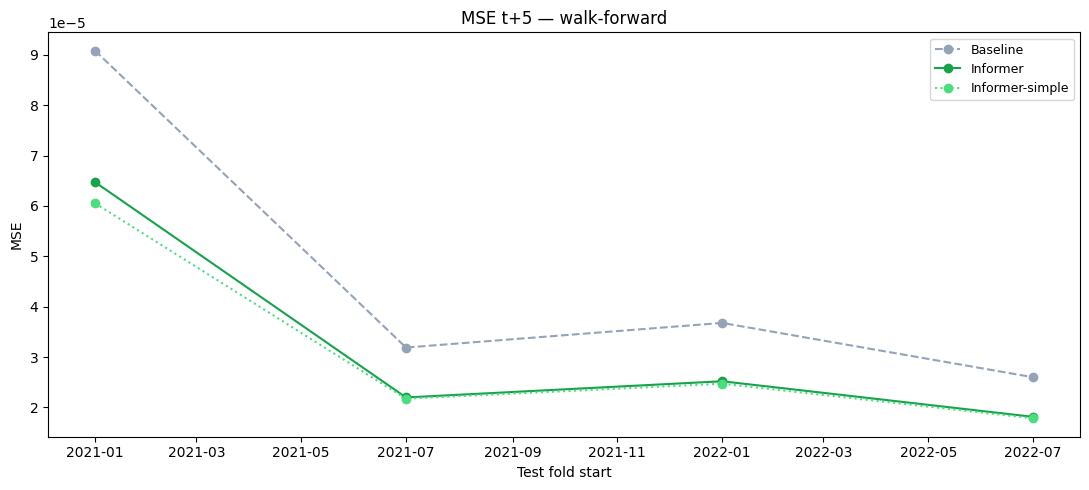

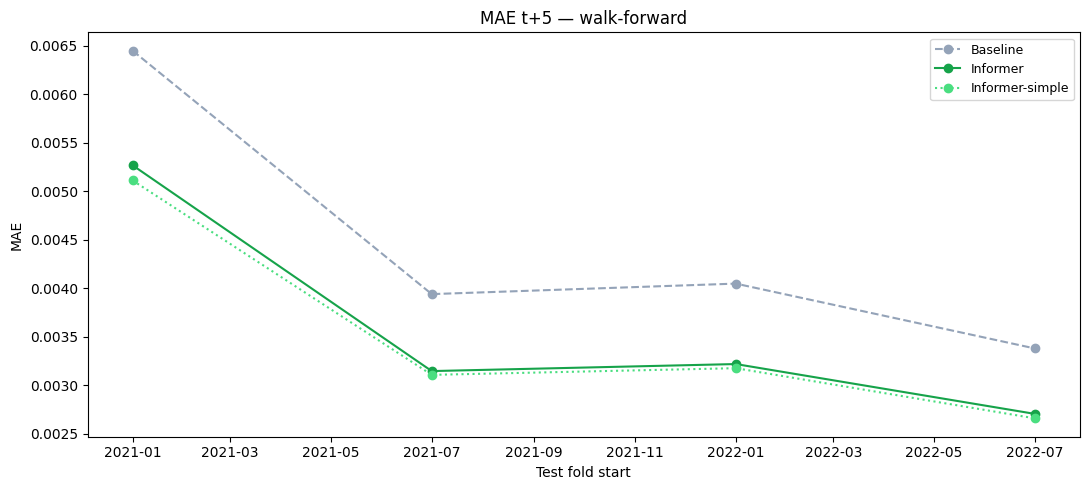

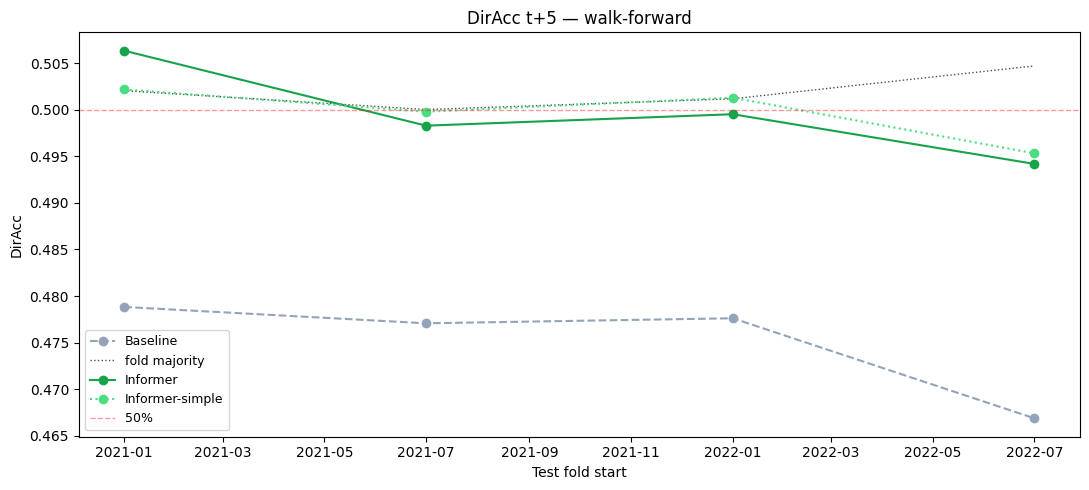

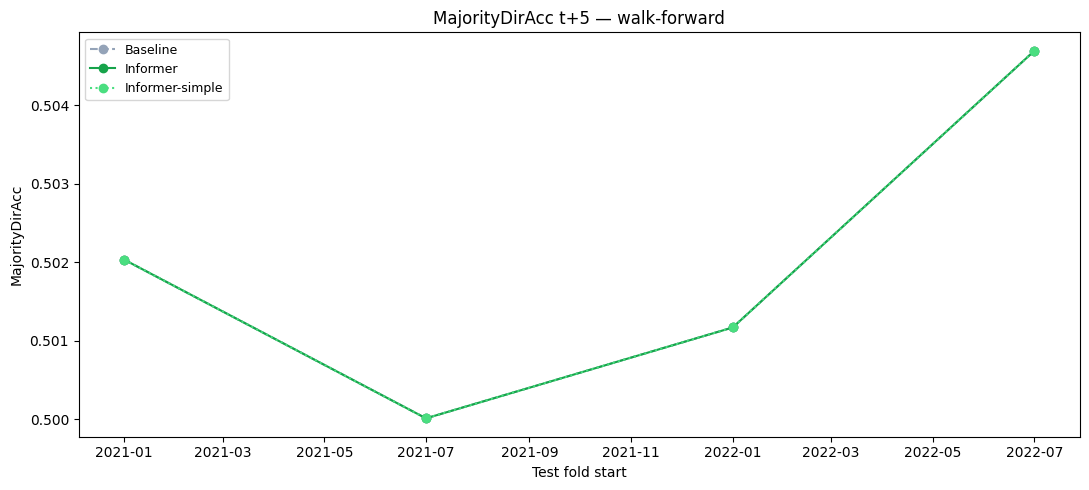

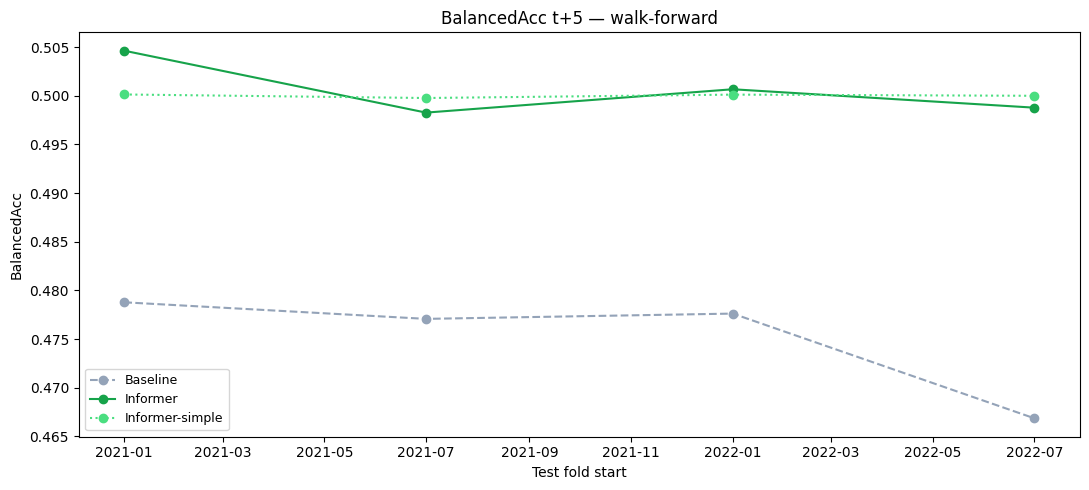

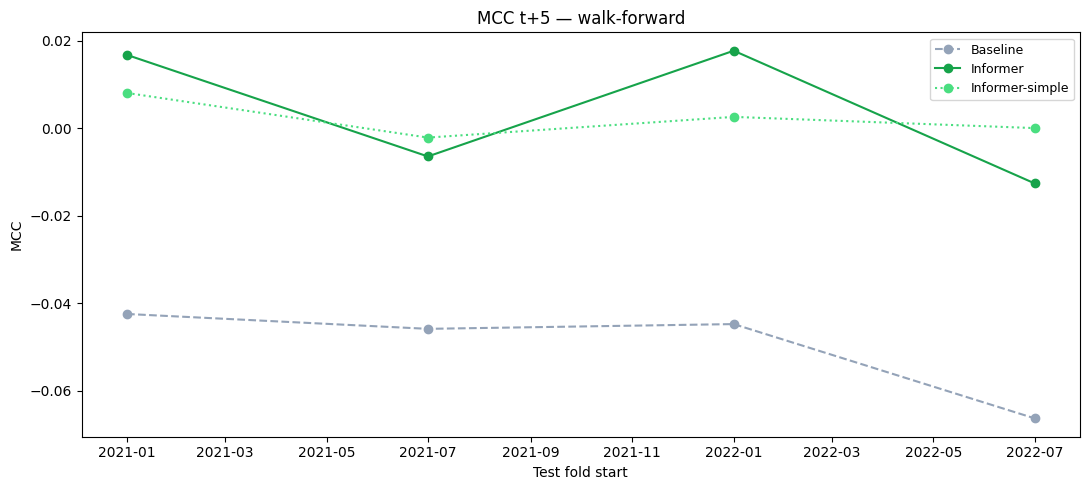

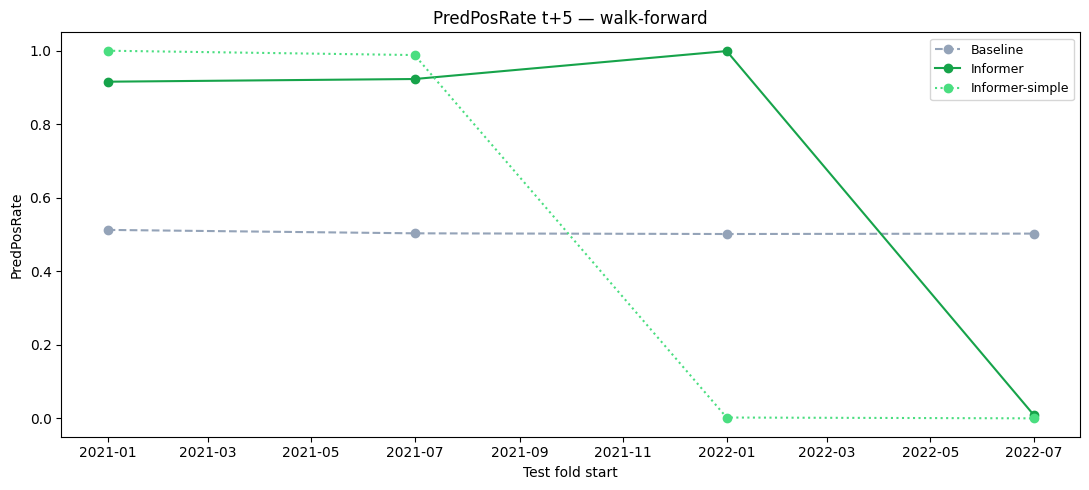

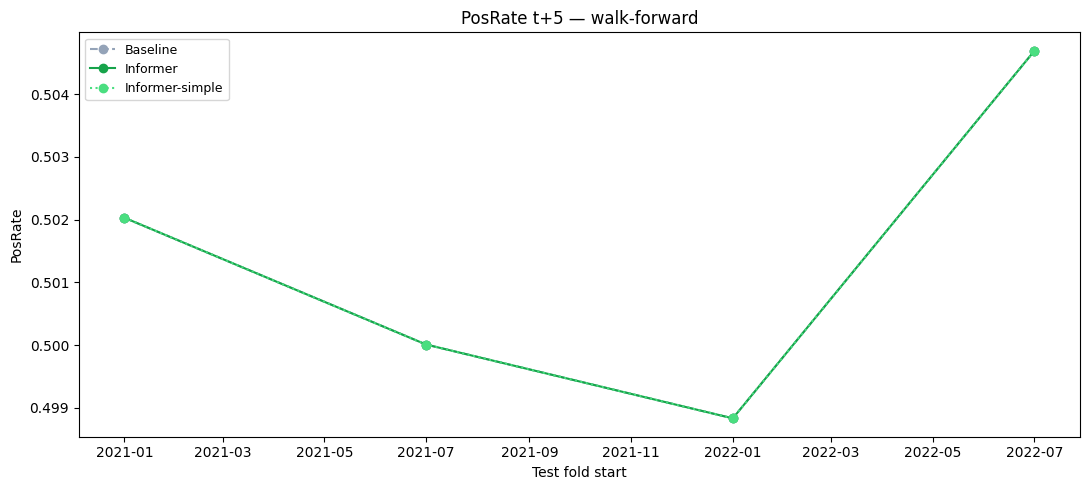

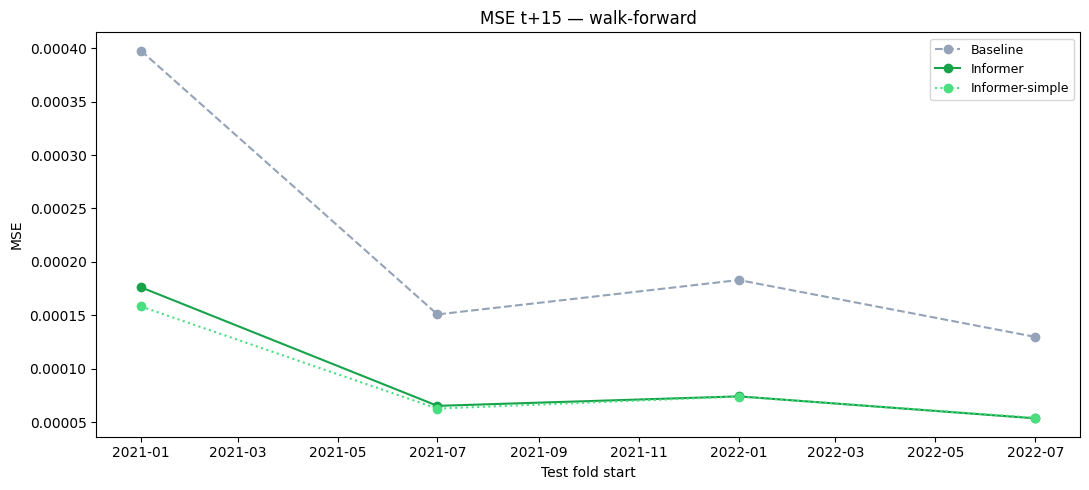

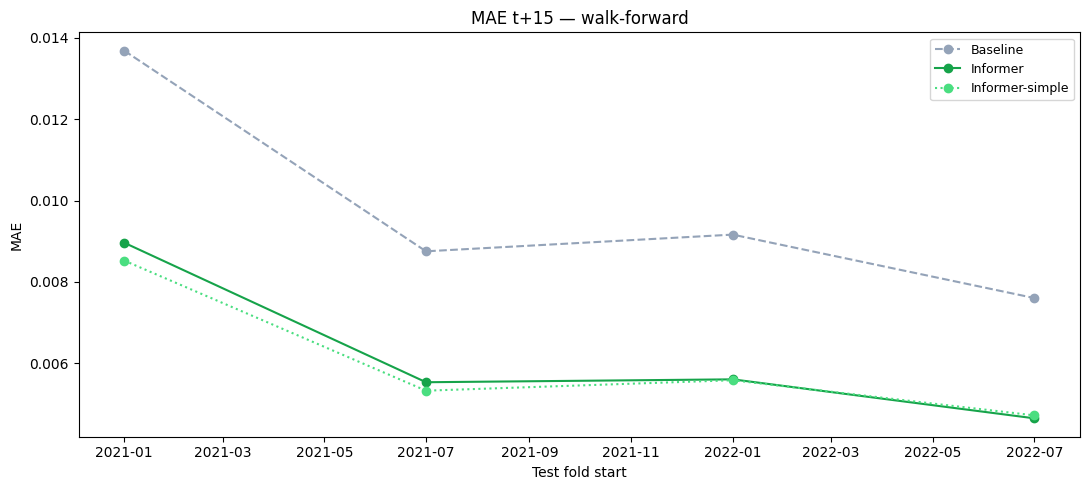

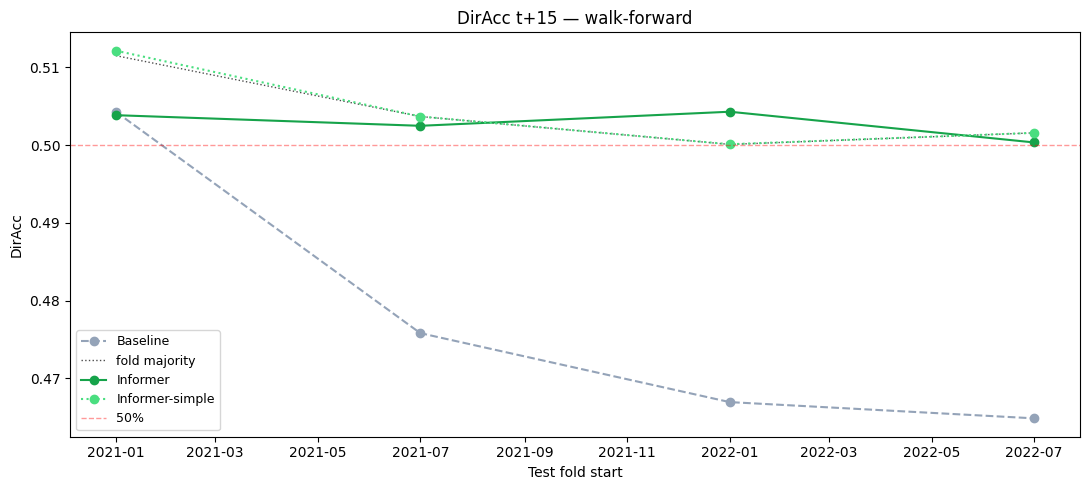

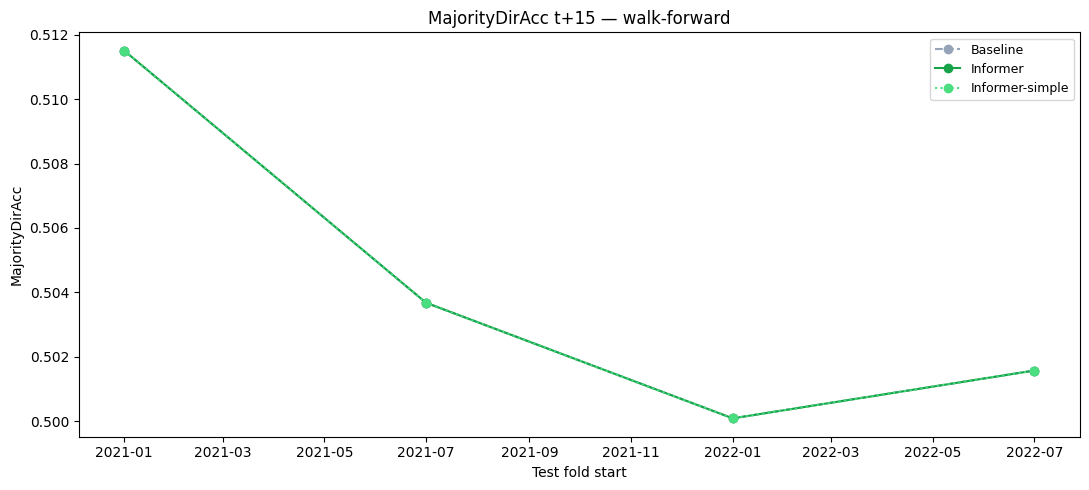

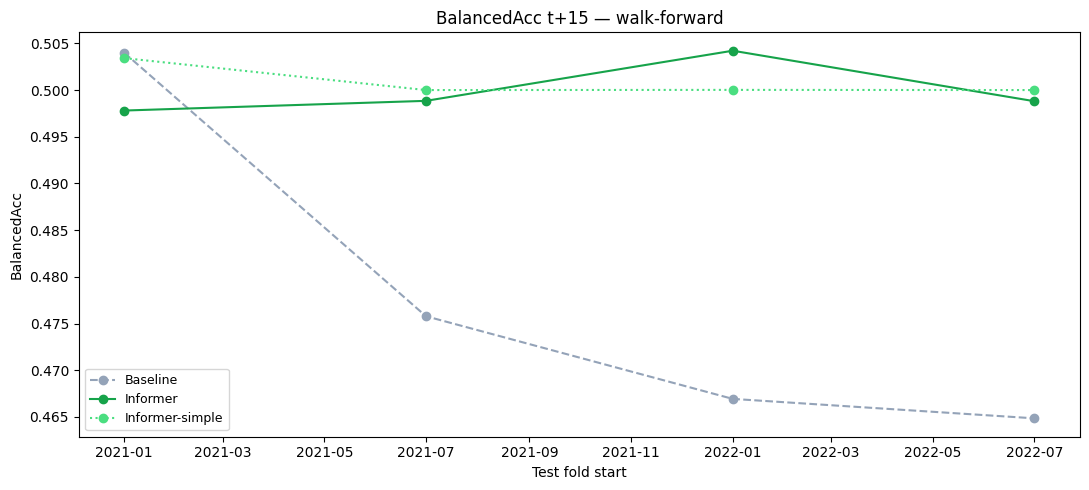

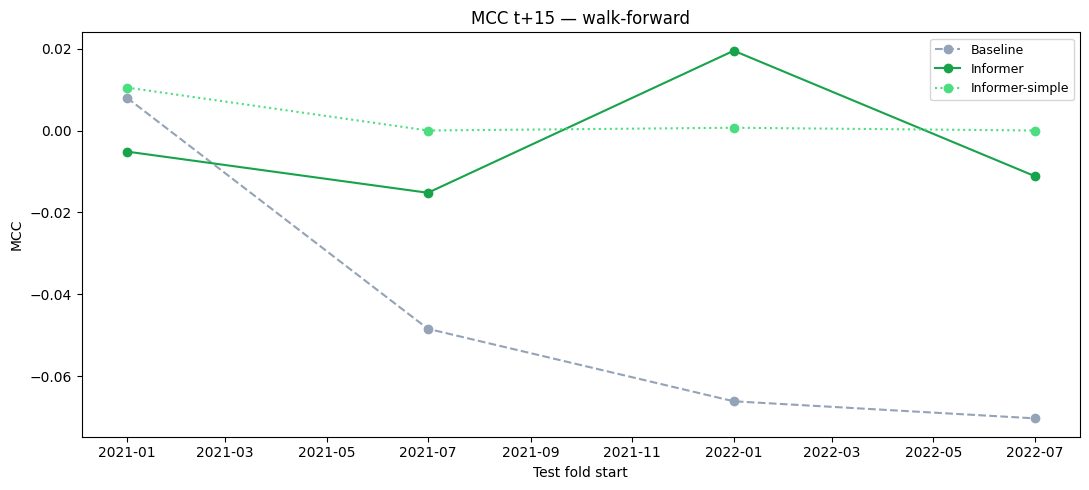

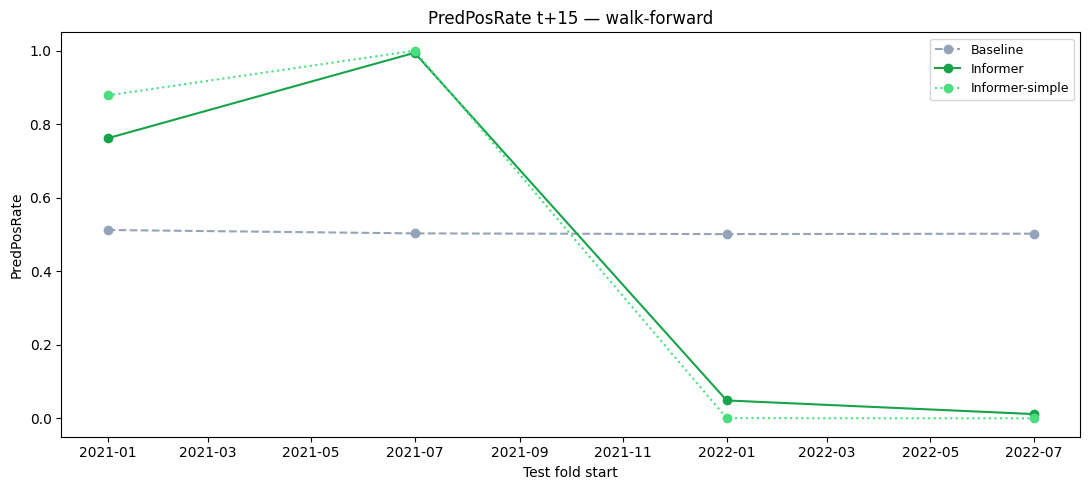

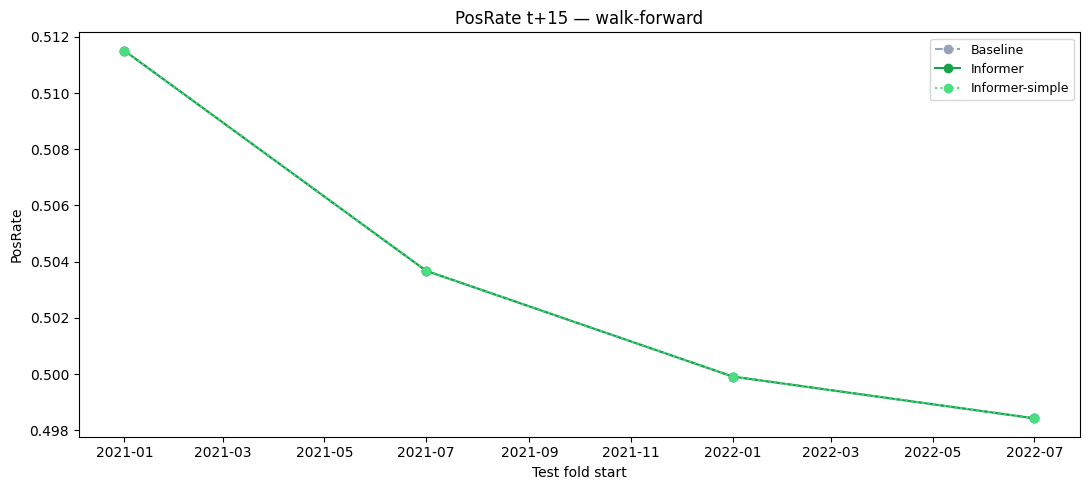

In [20]:
# ── Simple (BTC-USDT close-only) ──
inf_hp_simple = run_hp_search_coarse_to_fine(
    informer_factory, INFORMER_GRID, btc_df,
    os.path.join(RESULTS, "informer-simple"),
    filter_fn=lambda t: t["d_model"] % t["n_heads"] == 0,
    n_random=6, dataset_class=BinanceDatasetSimple,
)
display(inf_hp_simple.head())

run_walk_forward(
    informer_factory, inf_hp_simple.iloc[0],
    btc_df, FOLDS, os.path.join(RESULTS, "informer-simple"),
    dataset_class=BinanceDatasetSimple,
)

compare_model_family("Informer", "informer", "informer-simple")


## iTransformer

**Inverted dimensions**: variables become tokens, time steps become the embedding dim. With N variables each becomes one token of length L → linear projection to `d_model`. The `pool` hyperparameter picks between using just the BTC-USDT variable's encoded token or averaging all tokens.

In [21]:
def make_itransformer_factory(target_idx):
    def factory(n_features, d_model, n_heads, e_layers, dropout, pool):
        return iTransformerForecaster(
            n_features=n_features, d_model=d_model, n_heads=n_heads,
            e_layers=e_layers, dropout=dropout, n_horizons=len(HORIZONS),
            lookback=LOOKBACK, target_idx=target_idx, pool=pool,
        )
    return factory

ITRANSFORMER_GRID = {
    "d_model":  [64, 128],
    "n_heads":  [4, 8],
    "e_layers": [2, 3],
    "dropout":  [0.1, 0.2],
    "pool":     ["target_token", "mean"],
    "lr":       [1e-3, 5e-4],
}

# ── Full ──
it_hp_full = run_hp_search_coarse_to_fine(
    make_itransformer_factory(TARGET_FEAT_IDX_FULL),
    ITRANSFORMER_GRID, pair_data, os.path.join(RESULTS, "itransformer"),
    filter_fn=lambda t: t["d_model"] % t["n_heads"] == 0,
    n_random=6, dataset_class=BinanceDataset,
)
display(it_hp_full.head())

run_walk_forward(
    make_itransformer_factory(TARGET_FEAT_IDX_FULL), it_hp_full.iloc[0],
    pair_data, FOLDS, os.path.join(RESULTS, "itransformer"),
    dataset_class=BinanceDataset,
)


Valid trials in grid: 64
Phase 1 (random): 6 trials
[  1/6] phase=random  d_model=64  n_heads=8  e_layers=3  dropout=0.2  pool=target_token  lr=0.0005  

C:\Users\dimaz\AppData\Local\Temp\ipykernel_10864\2123005049.py:192: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(


  epoch   8 | train 0.97779 | val 0.54691  -> early stop
val_loss=0.545428  dir_acc=0.5117  bal_acc=0.5014  epoch=4
[  2/6] phase=random  d_model=64  n_heads=8  e_layers=3  dropout=0.2  pool=target_token  lr=0.001  

C:\Users\dimaz\AppData\Local\Temp\ipykernel_10864\2123005049.py:192: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(


  epoch   6 | train 0.99510 | val 0.56633  -> early stop
val_loss=0.546041  dir_acc=0.5107  bal_acc=0.5010  epoch=2
[  3/6] phase=random  d_model=64  n_heads=8  e_layers=3  dropout=0.1  pool=target_token  lr=0.001  

...

,d_model,n_heads,e_layers,dropout,pool,lr,phase,val_loss,dir_acc,balanced_acc,best_epoch,n_params
0,128,8,3,0.1,target_token,0.0010,refine,0.548489,0.513850,0.498402,3,611266
1,64,8,3,0.1,target_token,0.0010,random,0.544811,0.513318,0.497955,9,156130
2,64,8,3,0.2,target_token,0.0005,random,0.545428,0.511694,0.501358,4,156130
3,64,8,3,0.2,target_token,0.0010,random,0.546041,0.510696,0.500964,2,156130
4,128,4,2,0.1,mean,0.0005,random,0.548641,0.507837,0.494202,9,412994


Model params: {'d_model': 128, 'n_heads': 8, 'e_layers': 3, 'dropout': 0.1, 'pool': 'target_token'}    lr=0.001

--- Fold 1/4: train [2018-05-04 → 2020-12-31]  test [2021-01-01 → 2021-06-30] ---
  train=269962  val=8583  test=51720


C:\Users\dimaz\AppData\Local\Temp\ipykernel_10864\2123005049.py:192: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(


  epoch   7 | train 1.06503 | val 1.11530  -> early stop
  {'MSE_t5': 0.0001, 'MAE_t5': 0.0051, 'DirAcc_t5': 0.5008, 'BalancedAcc_t5': 0.4989, 'MCC_t5': -0.008, 'MSE_t15': 0.0002, 'MAE_t15': 0.0085, 'DirAcc_t15': 0.5067, 'BalancedAcc_t15': 0.4978, 'MCC_t15': -0.0069, 'PredPosRate_t5': 0.9794, 'PosRate_t5': 0.502, 'MajorityDirAcc_t5': 0.502, 'PredPosRate_t15': 0.8874, 'PosRate_t15': 0.5115, 'MajorityDirAcc_t15': 0.5115}

--- Fold 2/4: train [2018-05-04 → 2021-06-30]  test [2021-07-01 → 2021-12-31] ---
  train=321899  val=8641  test=52627
  epoch  10 | train 1.02877 | val 1.66769
  epoch  11 | train 1.01943 | val 1.67094  -> early stop
  {'MSE_t5': 0.0, 'MAE_t5': 0.0031, 'DirAcc_t5': 0.5067, 'BalancedAcc_t5': 0.5067, 'MCC_t5': 0.0142, 'MSE_t15': 0.0001, 'MAE_t15': 0.0053, 'DirAcc_t15': 0.5027, 'BalancedAcc_t15': 0.5048, 'MCC_t15': 0.0117, 'PredPosRate_t5': 0.6715, 'PosRate_t5': 0.5, 'MajorityDirAcc_t5': 0.5, 'PredPosRate_t15': 0.2144, 'PosRate_t15': 0.5037, 'MajorityDirAcc_t15': 0.5037}


([{'MSE_t5': 6.051879609003663e-05,
   'MAE_t5': 0.005105176009237766,
   'DirAcc_t5': 0.5008120649651973,
   'BalancedAcc_t5': 0.498865335610939,
   'MCC_t5': -0.007997163877696355,
   'MSE_t15': 0.00015845336019992828,
   'MAE_t15': 0.008522272109985352,
   'DirAcc_t15': 0.5067285382830626,
   'BalancedAcc_t15': 0.497813586117564,
   'MCC_t15': -0.0069152894257748995,
   'PredPosRate_t5': 0.9794470071792603,
   'PosRate_t5': 0.5020301342010498,
   'MajorityDirAcc_t5': 0.5020301342010498,
   'PredPosRate_t15': 0.887412965297699,
   'PosRate_t15': 0.5115042328834534,
   'MajorityDirAcc_t15': 0.5115042328834534,
   'test_from': '2021-01-01',
   'test_to': '2021-06-30'},
  {'MSE_t5': 2.204521297244355e-05,
   'MAE_t5': 0.0031491636764258146,
   'DirAcc_t5': 0.5066600794269102,
   'BalancedAcc_t5': 0.5066568206568118,
   'MCC_t5': 0.014173462710725393,
   'MSE_t15': 6.295778439380229e-05,
   'MAE_t15': 0.005346827674657106,
   'DirAcc_t15': 0.502688733919851,
   'BalancedAcc_t15': 0.50478

In [ ]:
# ── Simple (BTC-USDT close-only, n_features=1) ──
it_hp_simple = run_hp_search_coarse_to_fine(
    make_itransformer_factory(TARGET_FEAT_IDX_SIMPLE),
    ITRANSFORMER_GRID, btc_df, os.path.join(RESULTS, "itransformer-simple"),
    filter_fn=lambda t: t["d_model"] % t["n_heads"] == 0,
    n_random=6, dataset_class=BinanceDatasetSimple,
)
display(it_hp_simple.head())

run_walk_forward(
    make_itransformer_factory(TARGET_FEAT_IDX_SIMPLE), it_hp_simple.iloc[0],
    btc_df, FOLDS, os.path.join(RESULTS, "itransformer-simple"),
    dataset_class=BinanceDatasetSimple,
)

compare_model_family("iTransformer", "itransformer", "itransformer-simple")


## FEDformer

Replaces standard self-attention with **frequency-domain** attention: either Fourier-mode selection (`version="Fourier"`) or multi-wavelet decomposition (`version="Wavelets"`). FourierBlock has a hardcoded constraint of `n_heads == 8` in the upstream repo. Wavelet `c=8` to keep the model under ~1M params.

In [ ]:
def fedformer_factory(n_features, d_model, n_heads, e_layers, modes, version,
                      moving_avg, dropout, wavelet_c, wavelet_k):
    return FEDformerForecaster(
        n_features=n_features, d_model=d_model, n_heads=n_heads,
        e_layers=e_layers, modes=modes, version=version,
        moving_avg=moving_avg, dropout=dropout, n_horizons=len(HORIZONS),
        lookback=LOOKBACK, wavelet_c=wavelet_c, wavelet_k=wavelet_k,
    )

FEDFORMER_GRID = {
    "d_model":     [64, 128],
    "n_heads":     [8],            # FourierBlock hardcodes 8 heads
    "e_layers":    [2, 3],
    "modes":       [16, 32],
    "version":     ["Fourier", "Wavelets"],
    "moving_avg":  [13, 25],
    "dropout":     [0.1, 0.2],
    "wavelet_c":   [8],
    "wavelet_k":   [8],
    "lr":          [1e-3, 5e-4],
}

def fedformer_filter(t):
    if t["d_model"] % 8 != 0:
        return False
    # Wavelet path ignores `modes`, so dedupe by fixing it
    if t["version"] == "Wavelets" and t["modes"] != 16:
        return False
    return True

# ── Full ──
fed_hp_full = run_hp_search_coarse_to_fine(
    fedformer_factory, FEDFORMER_GRID, pair_data,
    os.path.join(RESULTS, "fedformer"),
    filter_fn=fedformer_filter, n_random=6, dataset_class=BinanceDataset,
)
display(fed_hp_full.head())

run_walk_forward(
    fedformer_factory, fed_hp_full.iloc[0],
    pair_data, FOLDS, os.path.join(RESULTS, "fedformer"),
    dataset_class=BinanceDataset,
)


In [ ]:
# ── Simple (BTC-USDT close-only) ──
fed_hp_simple = run_hp_search_coarse_to_fine(
    fedformer_factory, FEDFORMER_GRID, btc_df,
    os.path.join(RESULTS, "fedformer-simple"),
    filter_fn=fedformer_filter, n_random=6, dataset_class=BinanceDatasetSimple,
)
display(fed_hp_simple.head())

run_walk_forward(
    fedformer_factory, fed_hp_simple.iloc[0],
    btc_df, FOLDS, os.path.join(RESULTS, "fedformer-simple"),
    dataset_class=BinanceDatasetSimple,
)

compare_model_family("FEDformer", "fedformer", "fedformer-simple")


## FEiT — Frequency-Enhanced iTransformer

Custom hybrid: at the input, decompose each variable's series into trend (low-pass) and volatile (high-frequency) components. Both halves get embedded as separate tokens — `2N` tokens total — and fed through one shared encoder. The `pool="sp500_concat"` setting concatenates the trend and volatile tokens at the target index for the head; `pool="mean"` averages all `2N`. (The pool name is a relic of the original S&P codebase but it works for any `target_idx`.)

In [ ]:
def make_feit_factory(target_idx):
    def factory(n_features, d_model, n_heads, e_layers, dropout,
                version, modes, wavelet_level, moving_avg, pool):
        return FEiTransformerForecaster(
            n_features=n_features, d_model=d_model, n_heads=n_heads,
            e_layers=e_layers, dropout=dropout, n_horizons=len(HORIZONS),
            lookback=LOOKBACK, target_idx=target_idx, pool=pool,
            version=version, modes=modes, wavelet_level=wavelet_level,
            moving_avg=moving_avg,
        )
    return factory

# pool="sp500_concat" is the original repo's name for "concat trend+volatile target tokens";
# despite the name it works for any target_idx.
FEIT_GRID = {
    "d_model":       [64, 128],
    "n_heads":       [4, 8],
    "e_layers":      [2, 3],
    "dropout":       [0.1, 0.2],
    "version":       ["Fourier", "Wavelets"],
    "modes":         [16, 32],
    "wavelet_level": [2, 3],
    "moving_avg":    [13, 25],
    "pool":          ["sp500_concat", "mean"],
    "lr":            [1e-3, 5e-4],
}

def feit_filter(t):
    if t["d_model"] % t["n_heads"] != 0:
        return False
    if t["version"] == "Fourier" and t["wavelet_level"] != 2:    # dedupe Fourier trials
        return False
    if t["version"] == "Wavelets" and t["modes"] != 16:          # dedupe Wavelet trials
        return False
    return True

# ── Full ──
feit_hp_full = run_hp_search_coarse_to_fine(
    make_feit_factory(TARGET_FEAT_IDX_FULL),
    FEIT_GRID, pair_data, os.path.join(RESULTS, "feit"),
    filter_fn=feit_filter, n_random=8, dataset_class=BinanceDataset,
)
display(feit_hp_full.head())

run_walk_forward(
    make_feit_factory(TARGET_FEAT_IDX_FULL), feit_hp_full.iloc[0],
    pair_data, FOLDS, os.path.join(RESULTS, "feit"),
    dataset_class=BinanceDataset,
)


In [ ]:
# ── Simple (BTC-USDT close-only) ──
feit_hp_simple = run_hp_search_coarse_to_fine(
    make_feit_factory(TARGET_FEAT_IDX_SIMPLE),
    FEIT_GRID, btc_df, os.path.join(RESULTS, "feit-simple"),
    filter_fn=feit_filter, n_random=8, dataset_class=BinanceDatasetSimple,
)
display(feit_hp_simple.head())

run_walk_forward(
    make_feit_factory(TARGET_FEAT_IDX_SIMPLE), feit_hp_simple.iloc[0],
    btc_df, FOLDS, os.path.join(RESULTS, "feit-simple"),
    dataset_class=BinanceDatasetSimple,
)

compare_model_family("FEiT", "feit", "feit-simple")


## Final comparison

All 13 model variants in one table + per-metric, per-horizon walk-forward plots.

In [ ]:
# Aggregate every model's walk-forward results and render a single comparison table + plots.
ALL_MODELS = {
    "Baseline":            os.path.join(RESULTS, "baseline",            "walk_forward.json"),
    "Transformer":         os.path.join(RESULTS, "transformer",         "walk_forward.json"),
    "Transformer-simple":  os.path.join(RESULTS, "transformer-simple",  "walk_forward.json"),
    "PatchTST":            os.path.join(RESULTS, "patchtst",            "walk_forward.json"),
    "PatchTST-simple":     os.path.join(RESULTS, "patchtst-simple",     "walk_forward.json"),
    "Informer":            os.path.join(RESULTS, "informer",            "walk_forward.json"),
    "Informer-simple":     os.path.join(RESULTS, "informer-simple",     "walk_forward.json"),
    "iTransformer":        os.path.join(RESULTS, "itransformer",        "walk_forward.json"),
    "iTransformer-simple": os.path.join(RESULTS, "itransformer-simple", "walk_forward.json"),
    "FEDformer":           os.path.join(RESULTS, "fedformer",           "walk_forward.json"),
    "FEDformer-simple":    os.path.join(RESULTS, "fedformer-simple",    "walk_forward.json"),
    "FEiT":                os.path.join(RESULTS, "feit",                "walk_forward.json"),
    "FEiT-simple":         os.path.join(RESULTS, "feit-simple",         "walk_forward.json"),
}

print("=== All models — aggregate metrics ===")
display(summary_table(ALL_MODELS))

plot_walk_forward(ALL_MODELS, metrics=("MSE", "DirAcc", "BalancedAcc", "MCC"))
